1. read all variables
2. use the comnination of features 
3. export (which format)

# L1 data read

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import xarray as xr
from datetime import datetime, timedelta


from scipy import stats, interpolate
import os


#file_path = r'E:\CryoSat-2 L1\20220826-20220903Bofeaut sea\download_057a5345-d8d8-4264-9ee9-ae08943b4769_direct_download_result\CS_OFFL_SIR_SIN_1B_20220903T165247_20220903T165651_E001.nc'
#file_path = r'E:\CryoSat-2 L1\20220826-20220903Dynice region\SAR L1\CS_OFFL_SIR_SAR_1B_20220826T051930_20220826T052923_E001.nc'
#Dynice region
L1_path = r"E:\NWP\CS2_S1_matched\CS2\2023\CS_OFFL_SIR_SIN_1B_20230105T180803_20230105T180905_E001.nc"

# --- 2. 应用阈值进行分类 ---
# 设置初始阈值 (可以根据你的验证结果进行调整)
peakiness_threshold = 25
std_dev_threshold = 0.6

ds = xr.open_dataset(L1_path)

range_bins = 1024
# Read time and waveform data (automatically mapped)
time_20_ku = ds['time_20_ku'].values

lat_20_ku = ds['lat_20_ku'].values
lon_20_ku = ds['lon_20_ku'].values

waveform_20_ku = ds['pwr_waveform_20_ku'].values
waveform_plrm_01_ku = ds['pwr_waveform_plrm_01_ku'].values

noise_power_20_ku = ds['noise_power_20_ku'].values 
noise_power_real = np.where(noise_power_20_ku == -9999.99, np.nan, noise_power_20_ku )

# **Step 1: dB 转换回 线性功率**
noise_linear = 10 ** (noise_power_real / 10)  # 计算线性噪声功率 (13137,)
stack_std_20_ku = ds['stack_std_20_ku'].values #* 0.01
stack_peakiness_20_ku = ds['stack_peakiness_20_ku'].values # * 0.01
stack_kurtosis_20_ku = ds['stack_kurtosis_20_ku'].values #* 0.01 
window_del_20_ku = ds['window_del_20_ku'].values #*1e-12
tai_epoch = datetime(2000, 1, 1, 0, 0, 0)
alt = ds['alt_20_ku'].values
#alt_01 = ds['alt_plrm_01_ku'].values

def tai_to_utc(tai_seconds): # 将 TAI 秒数转换为 UTC 时间 
    utc_time = tai_epoch + timedelta(seconds=tai_seconds) 
    return utc_time

# Convert datetime64[ns] to seconds since epoch
tai_seconds = (time_20_ku - np.datetime64('2000-01-01T00:00:00')) / np.timedelta64(1, 's')
utc_time = np.array([tai_to_utc(t) for t in tai_seconds])


surf_type = ds["surf_type_01"].values  # 低频地表类型
ind_first_meas = ds["ind_first_meas_20hz_01"]#.values.astype(int)  # 对应的索引
# 20Hz 维度大小
N_20 = lat_20_ku.shape[0]

# 预填充 20Hz 的 surf_type 数组
surf_type_20hz = np.full(N_20, np.nan)

# 扩展 1Hz 的地表类型到 20Hz
for i in range(len(ind_first_meas)):
    start_idx = int(ind_first_meas[i])
    end_idx = min(start_idx + 20, N_20)  # 确保不越界
    surf_type_20hz[start_idx:end_idx] = surf_type[i]

# 确保 NetCDF 变量的维度名称正确
time_dim = "time_20_ku"  # 确保这个名字匹配 ds 的 20Hz 维度
if time_dim not in ds.dims:
    print("Warning: 维度名称不匹配，请检查 NetCDF 结构！")
    print(ds)  # 打印数据集以检查正确的维度名称
else:
    # 赋值前创建可修改副本
    ds = ds.copy()
    
    # 添加新变量
    ds["surf_type_20hz"] = (time_dim,), surf_type_20hz
    
# 假设你想创建一个 DataFrame 来存储所有这些变量
df = pd.DataFrame({
    'time_20_ku': time_20_ku,
    'utc_time': utc_time,
    'alt':alt,
    #'waveform_20_ku': list(waveform_20_ku),
    'noise_power_real': noise_power_real,
    'noise_linear': noise_linear,
    'std': stack_std_20_ku,
    'pp': stack_peakiness_20_ku,
    'k': stack_kurtosis_20_ku,
    'lat': lat_20_ku,
    'lon': lon_20_ku,
    'surf_type': surf_type_20hz,
    'window_del': window_del_20_ku
    #'waveform_20_ku': list(waveform_20_ku)
})

c = 299792458  # 光速 (m/s)
# 假设 df['window_del'] 是 timedelta64 类型
df['window_del_seconds'] = df['window_del'].dt.total_seconds() 

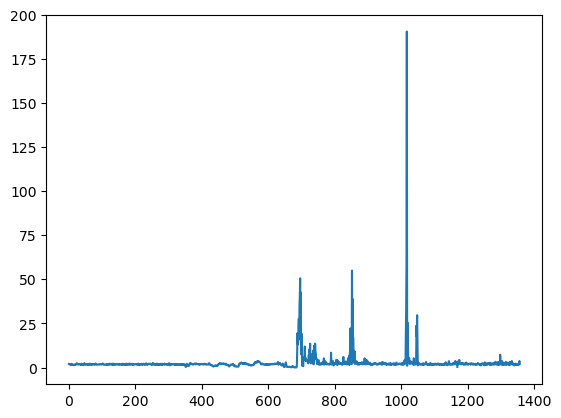

In [22]:
plt.plot(df['pp'], label='Peakiness')
# plt.plot(df['std'], label='Standard Deviation') 
# plt.plot(df['k'], label='Kurtosis')
plt.show()

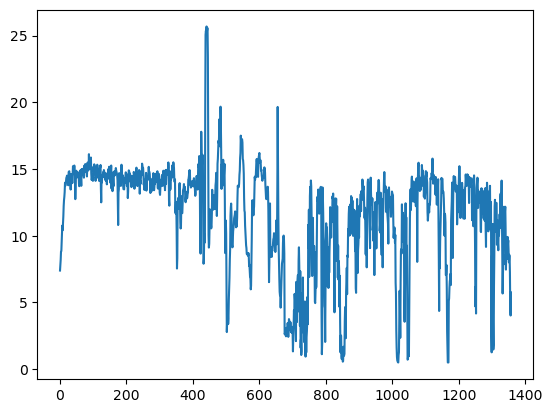

In [23]:
#plt.plot(df['pp'], label='Peakiness')
plt.plot(df['std'], label='Standard Deviation') 
# plt.plot(df['k'], label='Kurtosis')
plt.show()

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calculate_pulse_peakiness(waveform: np.ndarray) -> float:
    """
    根据论文中描述的方法，截取波形并计算脉冲峰值度 (PP)。

    步骤:
    1. 找到最大功率的索引 (b_max)。
    2. 以 b_max 为中心，定义一个从 b_max-50 到 b_max+77 的窗口。
    3. 创建一个128位的零数组，并将原始波形中对应窗口的数据填充进去，
       处理了边界情况 (即峰值靠近两端)。
    4. 在这个128位的截取波形上计算 P_max / P_mean。

    Args:
        waveform (np.ndarray): 输入的原始SAR/SARIn波形 (1D numpy array)。

    Returns:
        float: 计算出的脉冲峰值度 (PP) 值。如果平均功率为0，则返回 np.nan。
    """
    # 确保输入是 numpy 数组
    if not isinstance(waveform, np.ndarray):
        waveform = np.array(waveform)

    if waveform.size == 0:
        return np.nan

    # 1. 找到 b_max (最大返回功率的索引)
    b_max = np.argmax(waveform)

    # 2. 定义截取窗口的起始和结束索引
    start_index = b_max - 50
    end_index = b_max + 77  # 论文中的范围是包含两端的

    # 3. 创建一个128位的零数组用于存放截取结果
    cropped_waveform = np.zeros(128)

    # 计算源数据和目标数组的切片，以处理边界情况
    # 源数据切片 (在原始波形中)
    src_start = max(0, start_index)
    src_end = min(waveform.size, end_index + 1)
    
    # 目标数组切片 (在128位零数组中)
    dest_start = max(0, -start_index)
    dest_end = dest_start + (src_end - src_start)

    # 将数据从原始波形复制到128位数组中
    cropped_waveform[dest_start:dest_end] = waveform[src_start:src_end]

    # 4. 在截取出的128位波形上计算 PP
    p_max = np.max(cropped_waveform)
    p_mean = np.mean(cropped_waveform)

    # 避免除以零的错误
    if p_mean == 0:
        return np.nan
    
    pp = p_max / p_mean
    
    return pp

In [31]:
# --- 2. 应用函数 ---
# 使用列表推导式遍历 waveform_20_ku 的每一行
# waveform_20_ku 的每一行 (wf) 都是一个 (1024,) 的一维数组，可以直接传给函数
pp_results = [calculate_pulse_peakiness(wf) for wf in waveform_20_ku]
# --- 3. 将结果转换为NumPy数组 (可选，但推荐) ---
pp_results_np = np.array(pp_results)
df['pp_calculated'] = pp_results_np

# --- 检查结果 ---
print(f"原始波形数组的形状: {waveform_20_ku.shape}")
print(f"计算出的PP结果数组的形状: {pp_results_np.shape}")
print("\n前5个计算出的PP值:")
print(pp_results_np[:5])


原始波形数组的形状: (1358, 1024)
计算出的PP结果数组的形状: (1358,)

前5个计算出的PP值:
[3.95491616 2.94475943 4.06074897 4.66991783 4.05089894]


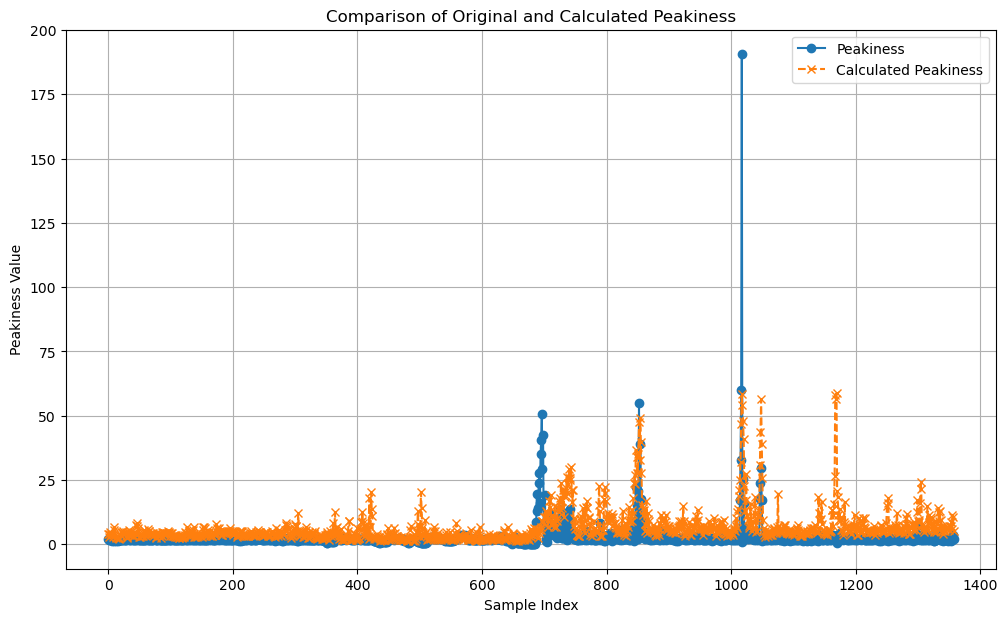

In [33]:
# --- 绘图代码 ---
plt.figure(figsize=(12, 7)) # 设置图形大小，让它更清晰

# 绘制原始的 Peakiness
plt.plot(df['pp'], label='Peakiness', marker='o', linestyle='-')

# 绘制你计算的 Peakiness
plt.plot(df['pp_calculated'], label='Calculated Peakiness', marker='x', linestyle='--')

# --- 添加图例、标题和标签 ---
plt.title('Comparison of Original and Calculated Peakiness') # 添加标题
plt.xlabel('Sample Index') # 添加 X 轴标签
plt.ylabel('Peakiness Value') # 添加 Y 轴标签
plt.grid(True) # 添加网格线，方便查看

plt.legend() # <-- 这是添加图例的关键命令

# --- 显示图形 ---
plt.show()

In [34]:
# 首先设置为 NaN
df['type'] = np.nan

# 条件1：极高的 pp + 低 std + 高 k → likely lead
mask_lead = (df['pp_calculated'] >= 18) & (df['std'] <= 4.62) 

# 条件2：较低的 pp + 高 std + 低 k → likely ice
mask_ice = (df['pp_calculated'] < 9) & (df['std'] > 4) 

# 再依据 pp 判断 lead 和 ice
df.loc[mask_lead | mask_ice, 'type'] = np.where(
    df.loc[mask_lead | mask_ice, 'pp_calculated'] >= 40, 'lead', 'ice'
)

lead_count = df['type'].value_counts().get('lead', 0)
ice_count = df['type'].value_counts().get('ice', 0) 
print(f"Lead count: {lead_count}")  
print(f"Ice count: {ice_count}")



Lead count: 12
Ice count: 1159


In [26]:
tai_epoch = datetime(2000, 1, 1, 0, 0, 0)
def tai_to_utc(tai_seconds): # 将 TAI 秒数转换为 UTC 时间 
    utc_time = tai_epoch + timedelta(seconds=tai_seconds) 
    return utc_time

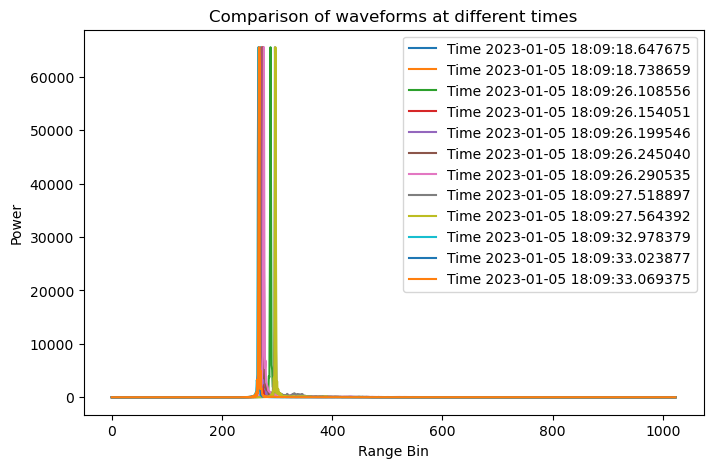

In [35]:
# 画图：把被判为 lead 的波形在地图投影顺序（轨迹）上画出 waveform 曲线（保存每个为一个 png）
lead_indices = df.index[df['type'] == 'lead'].tolist()
plt.figure(figsize=(8, 5))

for i in lead_indices:
    # Convert datetime64[ns] to seconds since epoch
    tai_seconds = (time_20_ku[i] - np.datetime64('2000-01-01T00:00:00')) / np.timedelta64(1, 's')
    utc_time = tai_to_utc(tai_seconds)
    plt.plot(waveform_20_ku[i, :], label=f'Time {utc_time}')

plt.xlabel('Range Bin')
plt.ylabel('Power')
plt.title('Comparison of waveforms at different times')
plt.legend()
plt.show()


In [4]:
import numpy as np
import scipy.ndimage
import netCDF4 as nc
import matplotlib.pyplot as plt

# 对波形进行插值（10倍过采样）
def oversample_waveform(waveform, factor=10):
    """
    采用线性插值对波形进行 10 倍过采样
    """
    rangeBins = np.arange(waveform.shape[1])  # 原始采样点
    rangeBins_new = np.linspace(0, waveform.shape[1] - 1, waveform.shape[1] * factor)  # 过采样点
    waveform_interp = np.array([np.interp(rangeBins_new, rangeBins, w) for w in waveform])  # 对每条波形插值
    return waveform_interp
# 应用平滑滤波
def smooth_waveform(waveform_interp, mode="SAR"):
    """
    使用 box 滤波器平滑波形, SAR 模式窗口大小为 11.SARIn 为 21
    """
    filter_size = 11 if mode == "SAR" else 21
    waveform_smoothed = np.array([scipy.ndimage.uniform_filter1d(w, size=filter_size) for w in waveform_interp])
    return waveform_smoothed

# 归一化波形
def normalize_waveform(waveform_smoothed):
    """
    归一化，使最大值变为 1.0
    """
    max_vals = np.max(waveform_smoothed, axis=1, keepdims=True)
    waveform_normalized = waveform_smoothed / max_vals
    return waveform_normalized


def find_TFMRA_range(waveform_normalized, mode="SAR"):
    """
    计算 TFMRA 反演点，确保 max_idx 选取真正的波峰
    """
    threshold_first_max = 0.15 if mode == "SAR" else 0.5  # 第一峰值阈值
    retrack_threshold = 0.5  # 50% 阈值
    bin_size = 0.2342  # 每个 bin 代表的物理距离 (m)
    #bin_size = 0.4684
    retracker_range = np.full(waveform_normalized.shape[0], np.nan)  # 初始化结果
    
    for i, waveform in enumerate(waveform_normalized):
        # 1. 找到所有波峰（局部最大值）
        peaks, _ = scipy.signal.find_peaks(waveform)
        
        if len(peaks) == 0:
            print(f"Warning: No peak found for waveform {i}")
            continue  # 跳过无峰值的波形
        
        # 2. 找到第一个大于 threshold_first_max 的真正波峰
        valid_peaks = [p for p in peaks if waveform[p] > threshold_first_max]
        if not valid_peaks:
            print(f"Warning: No peak above threshold for waveform {i}")
            continue  # 跳过无合适波峰的波形
        
        max_idx = valid_peaks[0]  # 选取第一个超过阈值的波峰索引
        print(f"Waveform {i}: Selected peak at {max_idx}, value={waveform[max_idx]:.3f}")

        # 3. 在波峰前寻找 50% 截止点
        for j in range(max_idx):
            if waveform[j] <= retrack_threshold <= waveform[j + 1]:
                print('YES! Found retracker point!')
                frac = (retrack_threshold - waveform[j]) / (waveform[j + 1] - waveform[j])
                retracker_range[i] = j + frac
                print(f"Waveform {i} retracker bin: {retracker_range[i]}")
                break

    # 计算测量得到的 range_measured（不包括 window_del）
    #range_measured = retracker_range * (bin_size / 10)  # 10x 过采样后的 bin size
    range_correction = ( retracker_range -1280  )* (bin_size / 10)  # 10x 过采样后的 bin size
    return range_correction

def compute_final_range(range_correction, window_del):
    """
    计算最终的 range
    """
    c = 299792458  # 光速 (m/s)
    window_del_seconds = window_del # * 1e-12  # 由 CryoSat-2 L1B 文件中的 scale_factor 确定
    range_final = (window_del_seconds * c) / 2 + range_correction
    
    return range_final

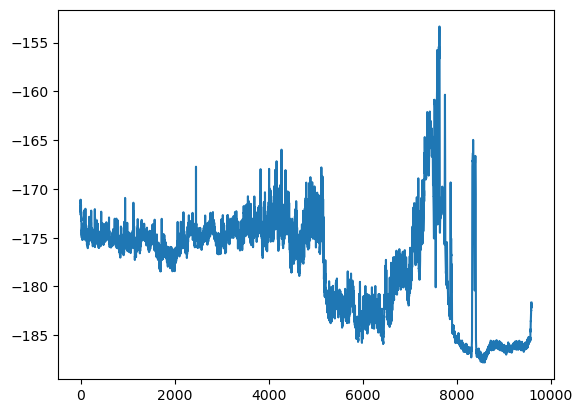

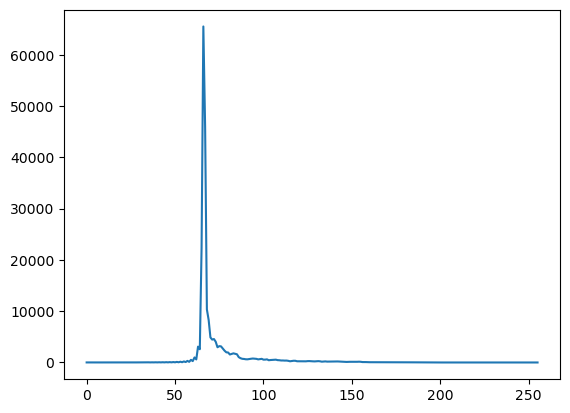

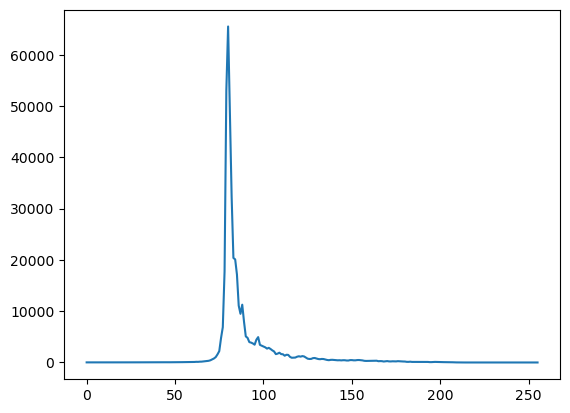

-173.99
-176.11


In [5]:
plt.plot(noise_power_20_ku)
plt.show()
plt.plot(waveform_20_ku[100])
plt.show()
plt.plot(waveform_20_ku[1000])      
plt.show()

print(noise_power_20_ku[100])
print(noise_power_20_ku[1000])

Waveform 0: Selected peak at 753, value=1.000
YES! Found retracker point!
Waveform 0 retracker bin: 741.4915987618022
Waveform 1: Selected peak at 751, value=1.000
YES! Found retracker point!
Waveform 1 retracker bin: 737.9315613676584
Waveform 2: Selected peak at 687, value=1.000
YES! Found retracker point!
Waveform 2 retracker bin: 675.08163807392
Waveform 3: Selected peak at 704, value=1.000
YES! Found retracker point!
Waveform 3 retracker bin: 692.8575008505707
Waveform 4: Selected peak at 724, value=1.000
YES! Found retracker point!
Waveform 4 retracker bin: 708.871039345436
Waveform 5: Selected peak at 738, value=1.000
YES! Found retracker point!
Waveform 5 retracker bin: 725.8609286820745
Waveform 6: Selected peak at 675, value=1.000
YES! Found retracker point!
Waveform 6 retracker bin: 664.1589546104071
Waveform 7: Selected peak at 692, value=1.000
YES! Found retracker point!
Waveform 7 retracker bin: 678.6849697126376
Waveform 8: Selected peak at 711, value=1.000
YES! Found re

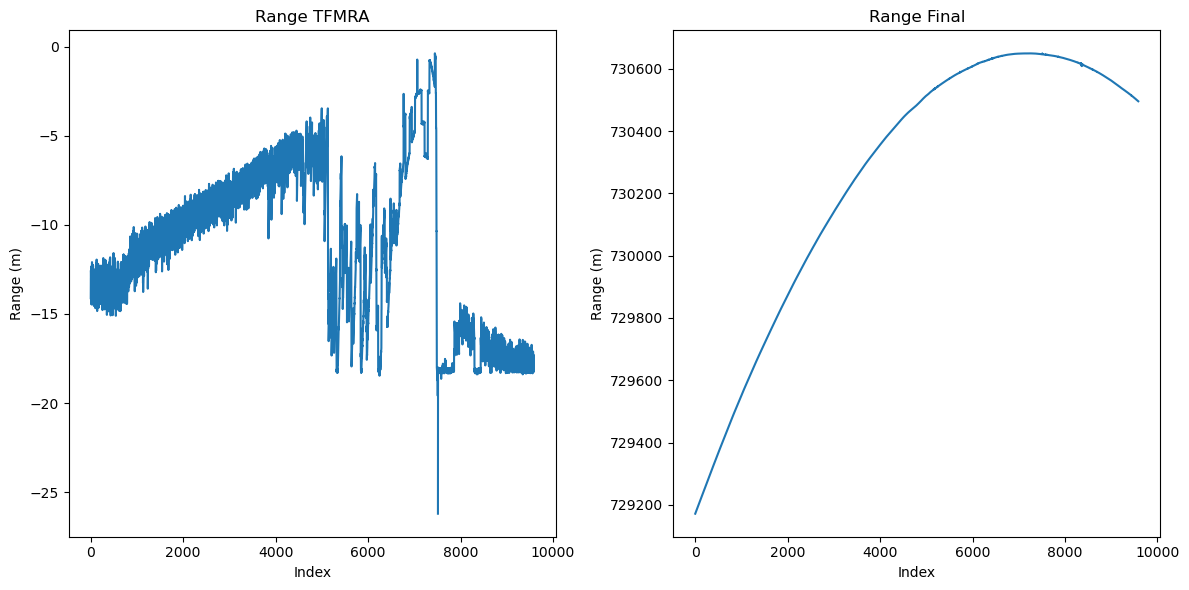

In [6]:
#waveform = np.array(df['waveform_20_ku'].tolist())
waveform = waveform_20_ku - noise_power_real[:, np.newaxis]

waveform_interp = oversample_waveform(waveform, factor=10)
waveform_smoothed = smooth_waveform(waveform_interp, 'SAR')
waveform_normalized = normalize_waveform(waveform_smoothed)
window_del = df['window_del_seconds'].values
range_TFMRA = find_TFMRA_range(waveform_normalized, mode="SAR")
c = 299792458  # 光速 (m/s)
range_window_del = df['window_del_seconds'].values*c/2  # 计算 window_del 对应的 range
range_final = compute_final_range(range_TFMRA, window_del)

# Assign TFMRA-related results to the DataFrame
df['range_TFMRA'] = range_TFMRA
df['range_final'] = range_final
df['range_window_del'] = range_window_del

plt.figure(figsize=(12, 6))

# Plot range_TFMRA
plt.subplot(1, 2, 1)
plt.plot(range_TFMRA)
plt.title('Range TFMRA')
plt.xlabel('Index')
plt.ylabel('Range (m)')

# Plot range_final
plt.subplot(1, 2, 2)
plt.plot(range_final)
plt.title('Range Final')
plt.xlabel('Index')
plt.ylabel('Range (m)')

plt.tight_layout()
plt.show()
plt.show()

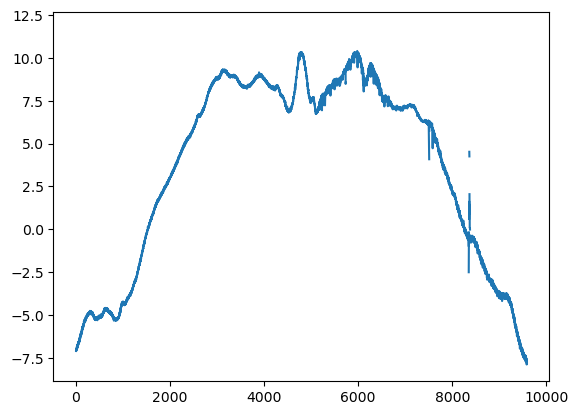

In [7]:
alt = ds['alt_20_ku'].values

temp = alt - range_final
df['temp'] = temp
plt.plot(temp)
plt.show()

In [8]:
df_L1 = df

In [9]:
from scipy.interpolate import griddata
mss_file = r"E:\CryoSat-2 L1\DTU21MSS_1min_WGS84.nc"
ds_mss = xr.open_dataset(mss_file)

# 转换经度范围 [0, 360] -> [-180, 180]
lon_mss = ds_mss['lon'].values
lat_mss = ds_mss['lat'].values
lon_mss[lon_mss > 180] -= 360

# meshgrid 成二维坐标点（MSS是规则网格）
lon_mss_grid, lat_mss_grid = np.meshgrid(lon_mss, lat_mss)
mss_data = ds_mss['mean_sea_surf_sol2'].values  # shape = (lat, lon)

In [10]:
import xarray as xr
import geopandas as gpd
import numpy as np
from scipy.interpolate import griddata

import numpy as np

# 从 df_L1 中获取经纬度边界
min_lon, max_lon = df_L1['lon'].min(), df_L1['lon'].max()
min_lat, max_lat = df_L1['lat'].min(), df_L1['lat'].max()

print(f"自动识别裁剪范围:lon({min_lon:.2f}, {max_lon:.2f}), lat({min_lat:.2f}, {max_lat:.2f})")

# 裁剪 MSS 数据（使用更安全的 where）
mss_clipped = ds_mss.where(
    (ds_mss.lon >= min_lon) & (ds_mss.lon <= max_lon) &
    (ds_mss.lat >= min_lat) & (ds_mss.lat <= max_lat),
    drop=True
)
lon_grid, lat_grid = np.meshgrid(mss_clipped.lon.values, mss_clipped.lat.values)
print(f"MSS 裁剪后尺寸:lon={mss_clipped.sizes['lon']}, lat={mss_clipped.sizes['lat']}")

# Flatten the 2D grid for use in griddata
mss_interp = griddata(
    (lon_grid.flatten(), lat_grid.flatten()),
    mss_clipped.mean_sea_surf_sol2.values.flatten(),
    (df_L1['lon'], df_L1['lat']),
    method='linear'
)

# 8. 将插值结果添加回原数据
df_L1['mss_interp'] = (mss_interp)

print("MSS 数据处理完成，并已插值到轨迹点！")

自动识别裁剪范围:lon(-180.00, 179.94), lat(76.24, 87.98)
MSS 裁剪后尺寸:lon=21596, lat=704
MSS 数据处理完成，并已插值到轨迹点！


### mss插值数据看起来没问题，接下来检查range

correction data read

In [11]:
# Read time and waveform data (automatically mapped)
time_20_ku = ds['time_20_ku'].values
time_cor_01= ds['time_cor_01'].values

waveform_20_ku = ds['pwr_waveform_20_ku'].values


#iono_cor_gim_01 = ds['iono_cor_gim_01'].values #* 0.001
iono_cor_01 = ds['iono_cor_01'].values #* 0.001
mod_dry_tropo_cor_01 = ds['mod_dry_tropo_cor_01'].values # * 0.001  # 应用缩放因子
mod_wet_tropo_cor_01= ds['mod_wet_tropo_cor_01'].values #* 0.001
inv_bar_cor_01 = ds['inv_bar_cor_01'].values #* 0.001
#hf_fluct_total_cor_01 = ds['hf_fluct_total_cor_01'].values #* 0.001

ocean_tide_01 = ds['ocean_tide_01'].values # elastic ocean tide
ocean_tide_eq_01 = ds['ocean_tide_eq_01'].values #long period ocean tide
load_tide_01 = ds['load_tide_01'].values #ocean loading tide
solid_earth_tide_01 = ds['solid_earth_tide_01'].values #* 0.001
pole_tide_01 = ds['pole_tide_01'].values #geocentric polar tide

flag_cor_status_01 = ds['flag_cor_status_01'].values
flag_cor_err_01 = ds['flag_cor_err_01'].values


tai_seconds = (time_20_ku[i] - np.datetime64('2000-01-01T00:00:00')) / np.timedelta64(1, 's')
utc_time = tai_to_utc(tai_seconds)



# 读取 20Hz 维度大小
N_20 = len(time_20_ku)

# 获取 1Hz 校正值的索引
ind_first_meas = ds["ind_first_meas_20hz_01"].values.astype(int)

# 需要扩展的校正值列表
correction_vars = [
    'mod_dry_tropo_cor_01', 'mod_wet_tropo_cor_01', 'inv_bar_cor_01', 
    'iono_cor_01', 
    'ocean_tide_01', 'ocean_tide_eq_01', 'load_tide_01', 
    'solid_earth_tide_01', 'pole_tide_01'
]

# 初始化存储扩展后的校正数据
corrections_20hz = {var: np.full(N_20, np.nan) for var in correction_vars}

# 遍历 1Hz 索引并扩展校正数据
for i in range(len(ind_first_meas)):
    start_idx = ind_first_meas[i]
    end_idx = min(start_idx + 20, N_20)  # 确保索引不超出范围

    for var in correction_vars:
        corrections_20hz[var][start_idx:end_idx] = ds[var].values[i]  # 复制 1Hz 值到 20Hz

# 创建 DataFrame，存储扩展后的校正数据
df_corrections_20hz = pd.DataFrame(corrections_20hz)
df_corrections_20hz["time_20_ku"] = time_20_ku

# 打印检查
print(df_corrections_20hz.head())

   mod_dry_tropo_cor_01  mod_wet_tropo_cor_01  inv_bar_cor_01  iono_cor_01  \
0                -2.325                -0.074          -0.119       -0.018   
1                -2.325                -0.074          -0.119       -0.018   
2                -2.325                -0.074          -0.119       -0.018   
3                -2.325                -0.074          -0.119       -0.018   
4                -2.325                -0.074          -0.119       -0.018   

   ocean_tide_01  ocean_tide_eq_01  load_tide_01  solid_earth_tide_01  \
0         -0.021             0.037        -0.003                -0.01   
1         -0.021             0.037        -0.003                -0.01   
2         -0.021             0.037        -0.003                -0.01   
3         -0.021             0.037        -0.003                -0.01   
4         -0.021             0.037        -0.003                -0.01   

   pole_tide_01                    time_20_ku  
0         0.003 2022-08-24 05:22:03.93885004

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


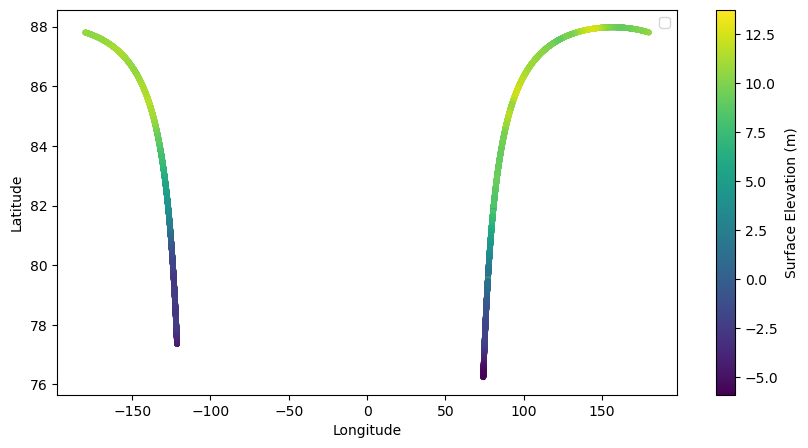

In [12]:
corrections_sum = sum(df_corrections_20hz[var] for var in correction_vars)
h_surface = alt - range_final - corrections_sum
df_L1['corrections_sum'] = corrections_sum
df_L1['h_surface'] = h_surface
df_L1['corrections_sum'] = corrections_sum 
df_L1['h_surface_no_TFMRA'] = alt - range_window_del + corrections_sum
# 5. 可视化地表高程
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sc = plt.scatter(df_L1["lon"], df_L1["lat"], c=h_surface, cmap="viridis", s=10)
plt.colorbar(sc, label="Surface Elevation (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend()
plt.show()

In [13]:
print(corrections_sum)

0      -2.530
1      -2.530
2      -2.530
3      -2.530
4      -2.530
        ...  
9582   -1.991
9583   -1.991
9584   -1.991
9585   -1.991
9586   -1.991
Length: 9587, dtype: float64


### for plotting distance calculation

In [13]:
from geopy.distance import geodesic
distance_km = [0]

for i in range(1, len(df_L1)):
    coord1 = (df_L1['lat'].iloc[i-1], df_L1['lon'].iloc[i-1])
    coord2 = (df_L1['lat'].iloc[i], df_L1['lon'].iloc[i])
    d = geodesic(coord1, coord2).km
    distance_km.append(distance_km[-1] + d)

df_L1['distance'] = distance_km

## calculate sea surface height anomaly

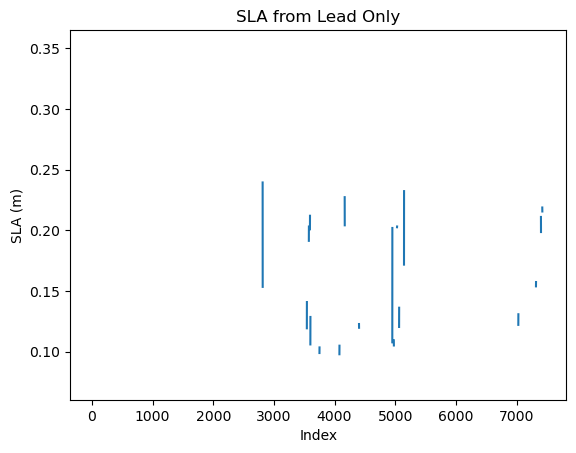

In [39]:
# 筛选出 lead (裂隙水面) 数据
lead_mask = (df_L1['type'] == 'lead')  # 'type' 可能需要确认列名
df_L1['SLA_raw'] = np.nan 
# 计算 SLA_raw
df_L1.loc[lead_mask, 'SLA_raw'] = df_L1.loc[lead_mask, 'h_surface'] - df_L1.loc[lead_mask, 'mss_interp']

#plt.plot(df_L1.loc[lead_mask, 'SLA_raw'])
plt.plot(df_L1['SLA_raw']) 
plt.title("SLA from Lead Only")
plt.xlabel("Index")
plt.ylabel("SLA (m)")
plt.show()



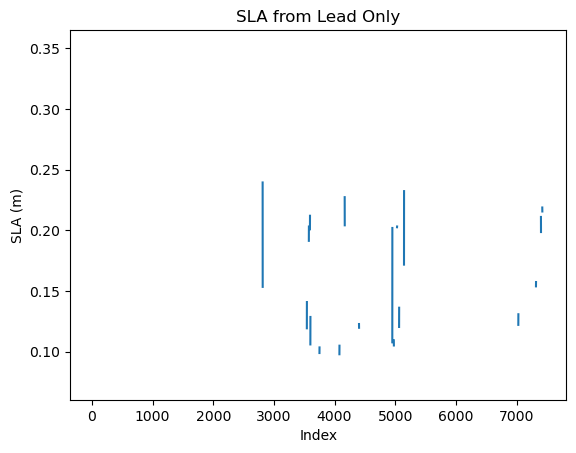

In [37]:
# 先创建两个空列
df_L1['height_sea_ice_floe'] = np.nan
df_L1['height_sea_ice_lead'] = np.nan

# 分别填充对应的 height 值
# 提取 height_sea_ice_lead 数据（带 NaN 保留原结构）
df_L1['height_sea_ice_lead'] = np.where(df_L1['type'] == 'lead', df_L1['h_surface'], np.nan)

df_L1['height_sea_ice_floe'] = np.where(df_L1['type'] == 'ice', df_L1['h_surface'], np.nan)


df_L1['SLA_raw1'] = df_L1['height_sea_ice_lead'] - df_L1['mss_interp']  

plt.plot(df_L1['SLA_raw1']) 
plt.title("SLA from Lead Only")
plt.xlabel("Index")
plt.ylabel("SLA (m)")
plt.show()


plt.plot() 默认是连线的
它会默认将数值连续地连接成线段。

掩膜 .loc[lead_mask, 'SLA_raw'] 是连续索引
lead_mask 会筛选出 'type' == 'lead' 的行，然后扔掉其他的行，也就是 丢掉了 NaN 和非-lead 的值，所以这时候传给 plot 的是一个没有 NaN 的连续向量。

👉 所以：它就直接画成了连续的线！

相反，df_L1['SLA_raw'] 包含了 NaN
所以这时候 plt.plot() 会自动“断开”线段，也就是哪里是 NaN，哪里就不画。

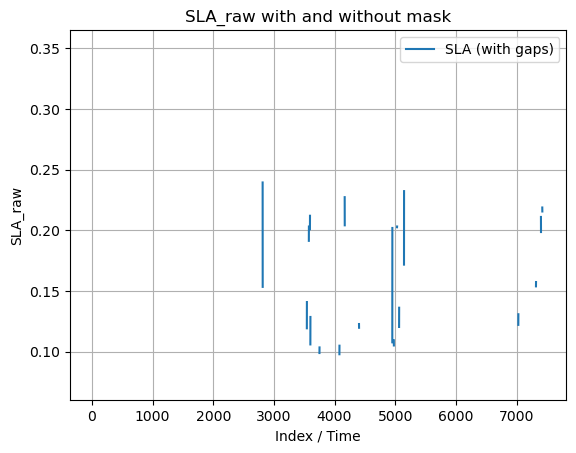

In [40]:
plt.plot(df_L1.index, df_L1['SLA_raw'], label='SLA (with gaps)')
plt.xlabel("Index / Time")
plt.ylabel("SLA_raw")
plt.legend()
plt.grid(True)
plt.title("SLA_raw with and without mask")
plt.show()


Mean SLA of this track (leads only): 0.173 m
✅ This track is within acceptable SLA range.


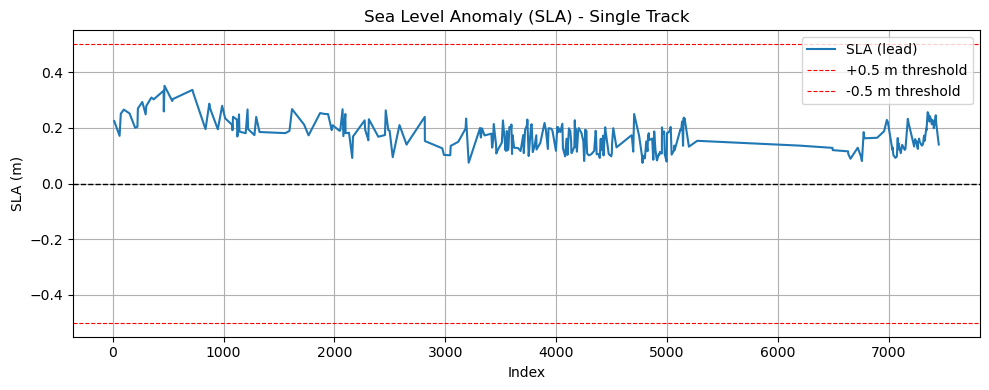

In [41]:
import matplotlib.pyplot as plt

# 1. 筛选出 lead（裂隙水面）数据
lead_mask = (df_L1['type'] == 'lead')

# 2. 计算原始 SLA（表面高度 - MSS）
df_L1.loc[lead_mask, 'SLA_raw'] = df_L1.loc[lead_mask, 'h_surface'] - df_L1.loc[lead_mask, 'mss_interp']

# 3. 移除异常 SLA（大于 ±20m 的点）
valid_sla_mask = (df_L1['SLA_raw'] > -20) & (df_L1['SLA_raw'] < 20)
df_L1 = df_L1[valid_sla_mask]

# 4. 重新筛选 lead（因为上一步删了一部分）
lead_mask = (df_L1['type'] == 'lead')

# 5. 计算该轨道的 mean SLA，仅基于 lead 点
mean_sla = df_L1.loc[lead_mask, 'SLA_raw'].mean()
print(f"Mean SLA of this track (leads only): {mean_sla:.3f} m")

# 6. 判断是否整体偏移
if abs(mean_sla) > 0.5:
    print("⚠️ Warning: This track has a mean SLA offset > ±0.5 m. Consider excluding it from analysis.")
else:
    print("✅ This track is within acceptable SLA range.")

# 7. 可视化
plt.figure(figsize=(10, 4))
plt.plot(df_L1.loc[lead_mask, 'SLA_raw'], label='SLA (lead)')
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.axhline(0.5, color='r', linestyle='--', linewidth=0.8, label='+0.5 m threshold')
plt.axhline(-0.5, color='r', linestyle='--', linewidth=0.8, label='-0.5 m threshold')
plt.title("Sea Level Anomaly (SLA) - Single Track")
plt.xlabel("Index")
plt.ylabel("SLA (m)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [42]:
from scipy.ndimage import uniform_filter1d
from scipy.interpolate import interp1d
import numpy as np

# 获取 lead 点的索引和经纬度
lead_indices = df_L1[lead_mask].index
lead_lons = df_L1.loc[lead_mask, 'lon']
lead_lats = df_L1.loc[lead_mask, 'lat']
SLA_raw_values = df_L1.loc[lead_mask, 'SLA_raw']

# Step 1: Box 平滑 (100 km)
SLA_smoothed = uniform_filter1d(SLA_raw_values, size=5, mode='nearest')  # 滑动窗口平滑

# Step 2: 线性插值
interp_func = interp1d(lead_indices, SLA_smoothed, kind='linear', bounds_error=False, fill_value="extrapolate")
df_L1['SLA'] = interp_func(df_L1.index)

# Step 3: 二次 Box 平滑 (100 km)
df_L1['SLA'] = uniform_filter1d(df_L1['SLA'], size=5, mode='nearest')

# Step 4: 超过 200 km 设为 NaN
df_L1['distance_to_nearest_lead'] = df_L1.index.to_series().apply(lambda x: np.abs(lead_indices - x).min())
df_L1.loc[df_L1['distance_to_nearest_lead'] > 200, 'SLA'] = np.nan

C:\Users\TJ002\AppData\Local\Temp\ipykernel_36288\831938827.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_L1['SLA'] = interp_func(df_L1.index)
C:\Users\TJ002\AppData\Local\Temp\ipykernel_36288\831938827.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_L1['SLA'] = uniform_filter1d(df_L1['SLA'], size=5, mode='nearest')
C:\Users\TJ002\AppData\Local\Temp\ipykernel_36288\831938827.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

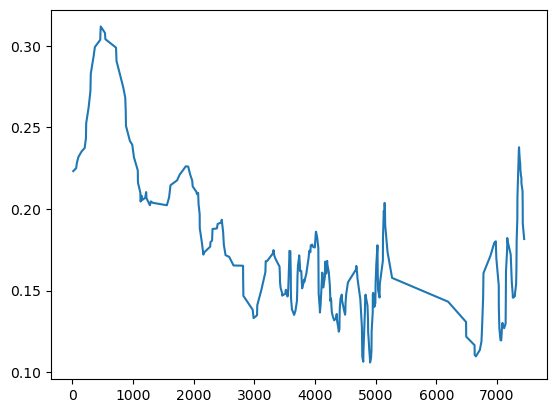

In [43]:
plt.plot(df_L1['SLA'])
plt.show()

# L2 read

In [15]:
L2_path = r"E:\CryoSat-2 L1\20220815-0930 Dyice region\CS_OFFL_SIR_SAR_2__20220824T052127_20220824T052840_E001.nc"
ds_L2 = xr.open_dataset(L2_path)

# Read time and waveform data (automatically mapped)
time_20_ku = ds_L2['time_20_ku'].values
height_1_20_ku = ds_L2['height_1_20_ku'].values
mss_seaIce = ds_L2['mean_sea_surf_sea_ice_01'].values
radar_freeboard = ds_L2['radar_freeboard_20_ku'].values
ssha = ds_L2['ssha_interp_20_ku'].values
lon = ds_L2['lon_poca_20_ku'].values
lat = ds_L2['lat_poca_20_ku'].values
lat_01 = ds_L2['lat_01'].values
lon_01 = ds_L2['lon_01'].values
range_1 = ds_L2['range_1_20_ku'].values
snow_density = ds_L2['snow_density_01'].values
snow_depth = ds_L2['snow_depth_01'].values
alt = ds_L2['alt_01'].values
height_sea_ice_floe = ds_L2['height_sea_ice_floe_20_ku'].values
height_sea_ice_lead = ds_L2['height_sea_ice_lead_20_ku'].values
surf_type = ds_L2['surf_type_20_ku'].values
tai_epoch = datetime(2000, 1, 1, 0, 0, 0)

def tai_to_utc(tai_seconds): # 将 TAI 秒数转换为 UTC 时间 
    utc_time = tai_epoch + timedelta(seconds=tai_seconds) 
    return utc_time

# Convert datetime64[ns] to seconds since epoch
tai_seconds = (time_20_ku - np.datetime64('2000-01-01T00:00:00')) / np.timedelta64(1, 's')
utc_time = np.array([tai_to_utc(t) for t in tai_seconds])



In [20]:
pp = ds_L2['peakiness_20_ku'].values


In [21]:
alt = ds_L2['alt_01'].values
print(alt)

[729164.758 729172.908 729181.037 729189.147 729197.236 729205.305
 729213.354 729221.383 729229.391 729237.38  729245.348 729253.295
 729261.222 729269.129 729277.016 729284.882 729292.728 729300.553
 729308.357 729316.142 729323.905 729331.648 729339.37  729347.072
 729354.753 729362.414 729370.053 729377.672 729385.27  729392.848
 729400.404 729407.94  729415.454 729422.948 729430.421 729437.873
 729445.304 729452.714 729460.103 729467.471 729474.818 729482.144
 729489.449 729496.732 729503.994 729511.236 729518.456 729525.654
 729532.832 729539.988 729547.123 729554.236 729561.328 729568.399
 729575.448 729582.476 729589.482 729596.467 729603.431 729610.372
 729617.293 729624.191 729631.069 729637.924 729644.758 729651.57
 729658.361 729665.13  729671.877 729678.602 729685.306 729691.988
 729698.648 729705.286 729711.902 729718.497 729725.069 729731.62
 729738.149 729744.656 729751.14  729757.603 729764.044 729770.463
 729776.859 729783.234 729789.586 729795.917 729802.225 729808.5

In [ ]:
print(range_1.shape)

(9587,)


## 没有indice,找最近点插值

In [16]:
# 假设你想创建一个 DataFrame 来存储所有这些变量
df_L2 = pd.DataFrame({
    'time_20_ku': time_20_ku,
    'utc_time': utc_time,
    'height_1_20_ku': height_1_20_ku,  
    'radar_freeboard': radar_freeboard,
    'ssha': ssha,
    'lat': lat,
    'lon': lon,
    'height_sea_ice_floe': height_sea_ice_floe,
    'height_sea_ice_lead': height_sea_ice_lead,
    'surf_type': surf_type,
})

In [17]:
import xarray as xr
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree



def match_nearest_valid_value(var_data, var_lat, var_lon, target_lat, target_lon, fill_value):
    """
    用于匹配最近的有效值 去除NaN或_FillValue),支持任意变量。

    参数：
    - var_data: 待匹配的变量数据（例如 mean_sea_surf_sea_ice_01)
    - var_lat: 变量数据对应的纬度lat_01
    - var_lon: 变量数据对应的经度lon_01
    - target_lat: 目标点的纬度height的点
    - target_lon: 目标点的经度height的点
    - fill_value: 该变量的 _FillValue,NaN也可以

    返回：
    - matched_values: 每个目标点匹配到的最近有效变量值
    """
    valid_mask = (var_data != fill_value)
    tree = cKDTree(np.c_[var_lat[valid_mask], var_lon[valid_mask]])
    distances, indices = tree.query(np.c_[target_lat, target_lon], k=1)
    matched_values = var_data[valid_mask][indices]
    return matched_values

# 读取 fill_value
fill_value_sss = ds_L2["mean_sea_surf_sea_ice_01"].attrs.get("_FillValue", np.nan)
fill_value_sd = ds_L2["snow_density_01"].attrs.get("_FillValue", np.nan)
fill_value_sdp = ds_L2["snow_depth_01"].attrs.get("_FillValue", np.nan)

# 匹配最近的值
matched_mean_sss = match_nearest_valid_value(mss_seaIce, lat_01, lon_01, lat, lon, fill_value_sss)
matched_snow_density = match_nearest_valid_value(snow_density, lat_01, lon_01, lat, lon, fill_value_sd)
matched_snow_depth = match_nearest_valid_value(snow_depth, lat_01, lon_01, lat, lon, fill_value_sdp)
matched_alt = match_nearest_valid_value(alt, lat_01, lon_01, lat, lon, fill_value_sd)

In [22]:
print(matched_mean_sss.shape)
print(mss_seaIce.shape)
print(lat.shape)

(9587,)
(480,)
(9587,)


In [18]:
# 假设你想创建一个 DataFrame 来存储所有这些变量
df_L2 = pd.DataFrame({
    'time_20_ku': time_20_ku,
    'utc_time': utc_time,
    'height_1_20_ku': height_1_20_ku,
    'mss_seaIce': matched_mean_sss,   
    'radar_freeboard': radar_freeboard,
    'ssha': ssha,
    'lat': lat,
    'lon': lon,
    'range_1': range_1,
    'snow_density': matched_snow_density,   
    'snow_depth': matched_snow_depth,
    'alt': matched_alt,
    'height_sea_ice_floe': height_sea_ice_floe,
    'height_sea_ice_lead': height_sea_ice_lead,
    'surf_type': surf_type,
})


In [26]:
print(df_L2.head())

                     time_20_ku                   utc_time  height_1_20_ku  \
0 2022-08-24 05:22:03.938850048 2022-08-24 05:22:03.938850          -4.807   
1 2022-08-24 05:22:03.983929088 2022-08-24 05:22:03.983929          -4.782   
2 2022-08-24 05:22:04.029008000 2022-08-24 05:22:04.029008          -4.780   
3 2022-08-24 05:22:04.074087040 2022-08-24 05:22:04.074087          -4.799   
4 2022-08-24 05:22:04.119166080 2022-08-24 05:22:04.119166          -4.698   

   mss_seaIce  radar_freeboard   ssha        lat         lon     range_1  \
0      -4.775              NaN -0.015  77.356262 -121.335881  729172.098   
1      -4.775              NaN -0.015  77.358944 -121.338071  729172.481   
2      -4.775              NaN -0.015  77.361627 -121.340262  729172.887   
3      -4.775              NaN -0.015  77.364310 -121.342454  729173.314   
4      -4.775              NaN -0.015  77.366992 -121.344646  729173.459   

   snow_density  snow_depth         alt  height_sea_ice_floe  \
0         

## read L2 correction

In [ ]:
#iono_cor_gim_01 = ds['iono_cor_gim_01'].values #* 0.001
iono_cor_01 = ds_L2['iono_cor_01'].values #* 0.001
mod_dry_tropo_cor_01 = ds_L2['mod_dry_tropo_cor_01'].values # * 0.001  # 应用缩放因子
mod_wet_tropo_cor_01= ds_L2['mod_wet_tropo_cor_01'].values #* 0.001
inv_bar_cor_01 = ds_L2['inv_bar_cor_01'].values #* 0.001
#hf_fluct_total_cor_01 = ds['hf_fluct_total_cor_01'].values #* 0.001

ocean_tide_01 = ds_L2['ocean_tide_01'].values # elastic ocean tide
ocean_tide_eq_01 = ds_L2['ocean_tide_eq_01'].values #long period ocean tide
load_tide_01 = ds_L2['load_tide_01'].values #ocean loading tide
solid_earth_tide_01 = ds_L2['solid_earth_tide_01'].values #* 0.001
pole_tide_01 = ds_L2['pole_tide_01'].values #geocentric polar tide
# 需要扩展的校正值列表
correction_vars = [
    'mod_dry_tropo_cor_01', 'mod_wet_tropo_cor_01', 'inv_bar_cor_01', 
    'iono_cor_01', 
    'ocean_tide_01', 'ocean_tide_eq_01', 'load_tide_01', 
    'solid_earth_tide_01', 'pole_tide_01'
]

corrections_sum = sum(df_corrections_20hz[var] for var in correction_vars)
df_L2['corrections_sum'] = corrections_sum

In [21]:
from geopy.distance import geodesic

distance_km = [0]

for i in range(1, len(df_L2)):
    coord1 = (df_L2['lat'].iloc[i-1], df_L2['lon'].iloc[i-1])
    coord2 = (df_L2['lat'].iloc[i], df_L2['lon'].iloc[i])
    d = geodesic(coord1, coord2).km
    distance_km.append(distance_km[-1] + d)

df_L2['distance'] = distance_km

## mss首先在L2插值确认与L2内部数据一致

In [29]:
from scipy.interpolate import griddata
mss_file = r"E:\CryoSat-2 L1\DTU21MSS_1min_WGS84.nc"
ds_mss = xr.open_dataset(mss_file)

# 转换经度范围 [0, 360] -> [-180, 180]
lon_mss = ds_mss['lon'].values
lat_mss = ds_mss['lat'].values
lon_mss[lon_mss > 180] -= 360

# meshgrid 成二维坐标点（MSS是规则网格）
lon_mss_grid, lat_mss_grid = np.meshgrid(lon_mss, lat_mss)
mss_data = ds_mss['mean_sea_surf_sol2'].values  # shape = (lat, lon)



重新设定region确保Mss插值有结果

In [30]:
import xarray as xr
import geopandas as gpd
import numpy as np
from scipy.interpolate import griddata

# 从 df_L1 中获取经纬度边界
min_lon, max_lon = df_L2['lon'].min(), df_L2['lon'].max()
min_lat, max_lat = df_L2['lat'].min(), df_L2['lat'].max()

print(f"自动识别裁剪范围:lon({min_lon:.2f}, {max_lon:.2f}), lat({min_lat:.2f}, {max_lat:.2f})")

# 裁剪 MSS 数据（使用更安全的 where）
mss_clipped_L2 = ds_mss.where(
    (ds_mss.lon >= min_lon) & (ds_mss.lon <= max_lon) &
    (ds_mss.lat >= min_lat) & (ds_mss.lat <= max_lat),
    drop=True
)
lon_grid_L2, lat_grid_L2 = np.meshgrid(mss_clipped_L2.lon.values, mss_clipped_L2.lat.values)
print(f"MSS 裁剪后尺寸:lon={mss_clipped_L2.sizes['lon']}, lat={mss_clipped_L2.sizes['lat']}")

# Flatten the 2D grid for use in griddata
mss_interp_L2 = griddata(
    (lon_grid_L2.flatten(), lat_grid_L2.flatten()),
    mss_clipped_L2.mean_sea_surf_sol2.values.flatten(),
    (df_L2['lon'], df_L2['lat']),
    method='linear'
)

# 8. 将插值结果添加回原数据
df_L2['mss_interp'] = (mss_interp_L2)


print("MSS 数据处理完成，并已插值到轨迹点！")



自动识别裁剪范围:lon(-180.00, 179.94), lat(76.24, 87.98)
MSS 裁剪后尺寸:lon=21596, lat=704
MSS 数据处理完成，并已插值到轨迹点！


### 原来是不在范围内才会是空值，需要重新设置lat_max. lon_max等边界

c:\Users\TJ002\anaconda3\envs\RadarEnv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


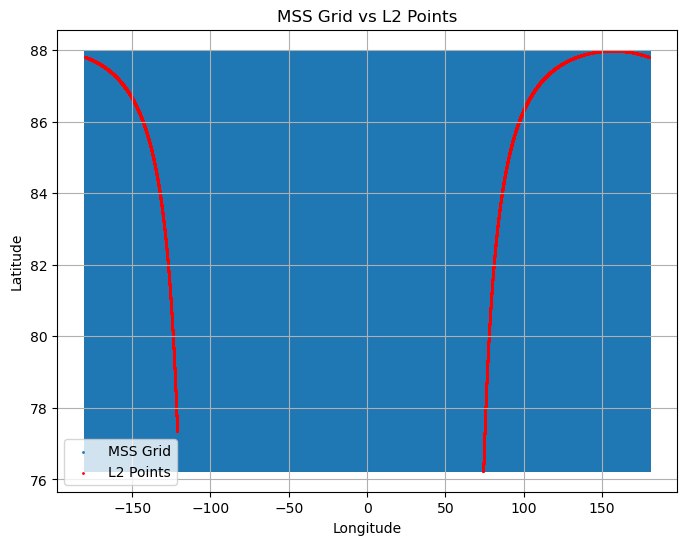

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(lon_grid.flatten(), lat_grid.flatten(), s=1, label='MSS Grid')
plt.scatter(df_L2['lon'], df_L2['lat'], color='red', s=1, label='L2 Points')
plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('MSS Grid vs L2 Points')
plt.grid(True)
plt.show()


In [ ]:
print(df_L2['mss_interp'].shape)
print(df_L2['mss_interp'].isnull().sum())

(9587,)
94


# plot for comparision

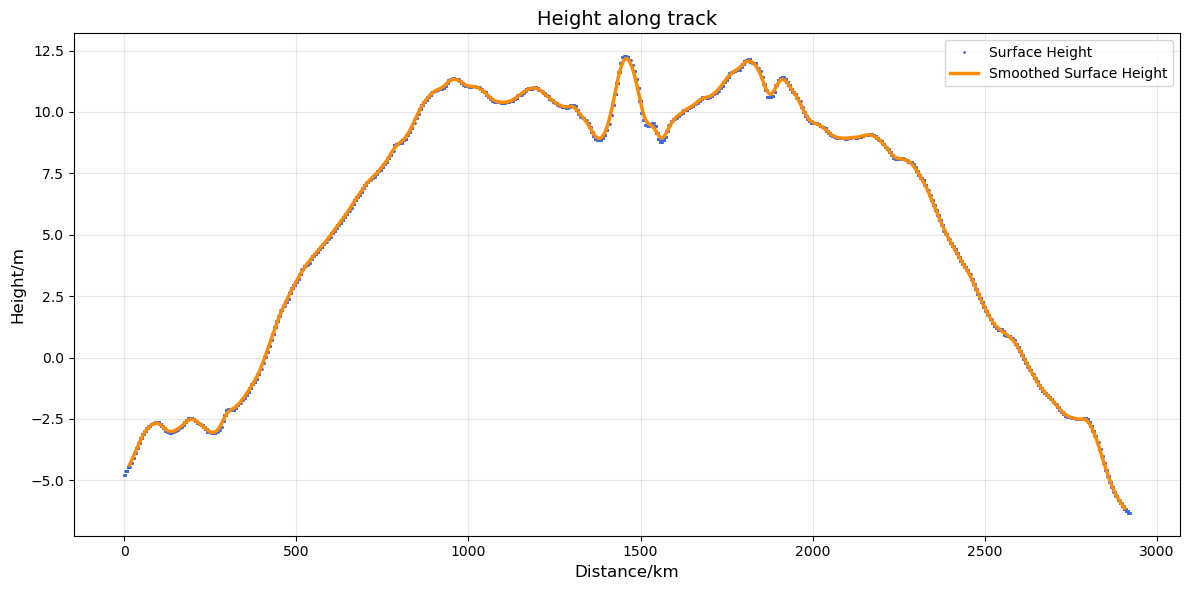

In [30]:
import matplotlib.pyplot as plt

# 示例：df 中包含 'distance' 和 'height_1_20_ku' 列
plt.figure(figsize=(12, 6))
#plt.plot(df_L2['distance'], df_L2['height_1_20_ku'], '.', color='royalblue', markersize=2, label='Surface Height')
plt.plot(df_L2['distance'], df_L2['mss_seaIce'], '.', color='royalblue', markersize=2, label='Surface Height')

# 可选平滑：移动平均 (window 可调)
window = 100
smooth = df_L2['mss_seaIce'].rolling(window, center=True).mean()
plt.plot(df_L2['distance'], smooth, color='darkorange', linewidth=2.5, label='Smoothed Surface Height')

plt.xlabel('Distance/km', fontsize=12)
plt.ylabel('Height/m', fontsize=12)
plt.title('Height along track', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


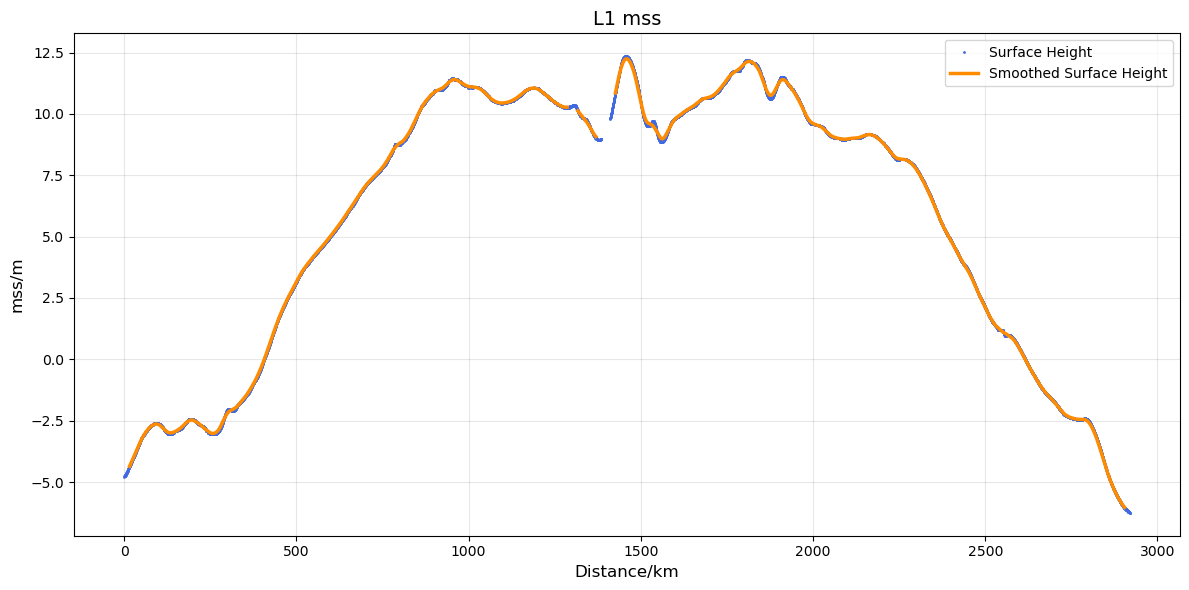

In [22]:
import matplotlib.pyplot as plt

# 示例：df 中包含 'distance' 和 'height_1_20_ku' 列
plt.figure(figsize=(12, 6))
#plt.plot(df_L2['distance'], df_L2['height_1_20_ku'], '.', color='royalblue', markersize=2, label='Surface Height')
plt.plot(df_L1['distance'], df_L1['mss_interp'], '.', color='royalblue', markersize=2, label='Surface Height')

# 可选平滑：移动平均 (window 可调)
window = 100
smooth = df_L1['mss_interp'].rolling(window, center=True).mean()
plt.plot(df_L1['distance'], smooth, color='darkorange', linewidth=2.5, label='Smoothed Surface Height')

plt.xlabel('Distance/km', fontsize=12)
plt.ylabel('mss/m', fontsize=12)
plt.title('L1 mss', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

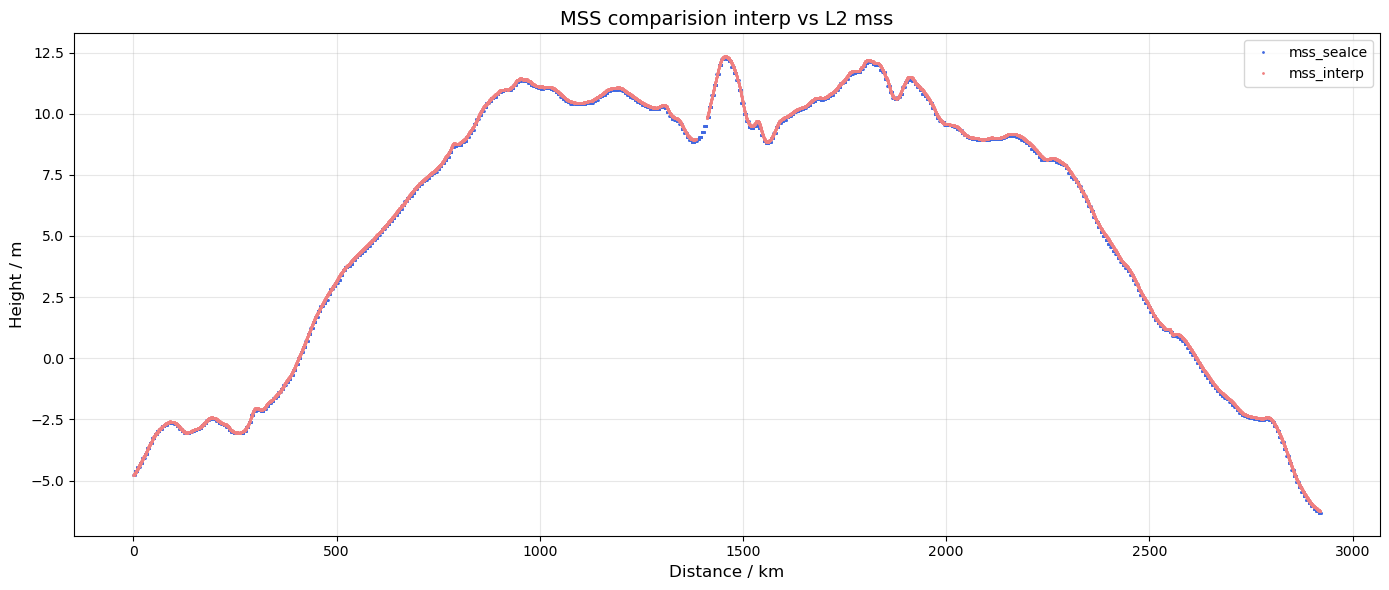

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# 原始点：mss_seaIce
plt.plot(df_L2['distance'], df_L2['mss_seaIce'], '.', color='royalblue', markersize=2, label='mss_seaIce')

# 原始点：mss_interp
plt.plot(df_L2['distance'], df_L2['mss_interp'], '.', color='lightcoral', markersize=2, label='mss_interp')

# 平滑曲线：mss_seaIce
#smooth_seaIce = df_L2['mss_seaIce'].rolling(window=100, center=True).mean()
#plt.plot(df_L2['distance'], smooth_seaIce, color='darkblue', linewidth=2.5, label='Smoothed mss_seaIce')

# 平滑曲线：mss_interp
#smooth_interp = df_L2['mss_interp'].rolling(window=100, center=True).mean()
#plt.plot(df_L2['distance'], smooth_interp, color='darkred', linewidth=2.5, label='Smoothed mss_interp')

# 图形设置
plt.xlabel('Distance / km', fontsize=12)
plt.ylabel('Height / m', fontsize=12)
plt.title('MSS comparision interp vs L2 mss', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### check the coverage of L1&L2

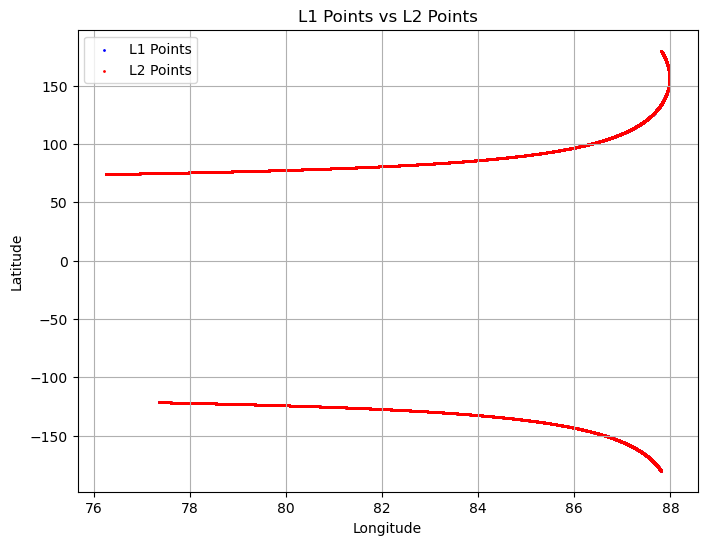

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(df_L1['lat'], df_L1['lon'], color='blue', s=1, label='L1 Points')
plt.scatter(df_L2['lat'], df_L2['lon'], color='red', s=1, label='L2 Points')
plt.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('L1 Points vs L2 Points')
plt.grid(True)
plt.show()

In [ ]:
print(df_L1['utc_time'].min(), df_L1['utc_time'].max())
print(df_L2['utc_time'].min(), df_L2['utc_time'].max())


2022-08-24 05:22:03.938850 2022-08-24 05:29:16.923159
2022-08-24 05:22:03.938850 2022-08-24 05:29:16.923159


In [ ]:
print(df_L1['distance'].head())
print(df_L2['distance'].head())


0    0.000000
1    0.304231
2    0.608475
3    0.912710
4    1.216946
Name: distance, dtype: float64
0    0.000000
1    0.304231
2    0.608475
3    0.912710
4    1.216946
Name: distance, dtype: float64


In [ ]:
print(df_L1[['lat', 'lon']].describe())
print(df_L2[['lat', 'lon']].describe())


               lat          lon
count  9587.000000  9587.000000
mean     82.985234    -7.115452
std       3.454769   116.731651
min      76.242516  -179.998524
25%      80.008778  -127.864277
50%      83.170085    75.278458
75%      86.162077    86.030125
max      87.978386   179.935936
               lat          lon
count  1980.000000  1980.000000
mean     79.997158  -124.305271
std       1.520893     2.022228
min      77.356262  -128.464165
25%      78.681631  -125.923487
50%      80.002128  -124.019438
75%      81.315369  -122.533450
max      82.617309  -121.335881


In [ ]:
print(len(df_L1), len(df_L2))


9587 1980


## plot L1 TFRMA range & L2_range_01

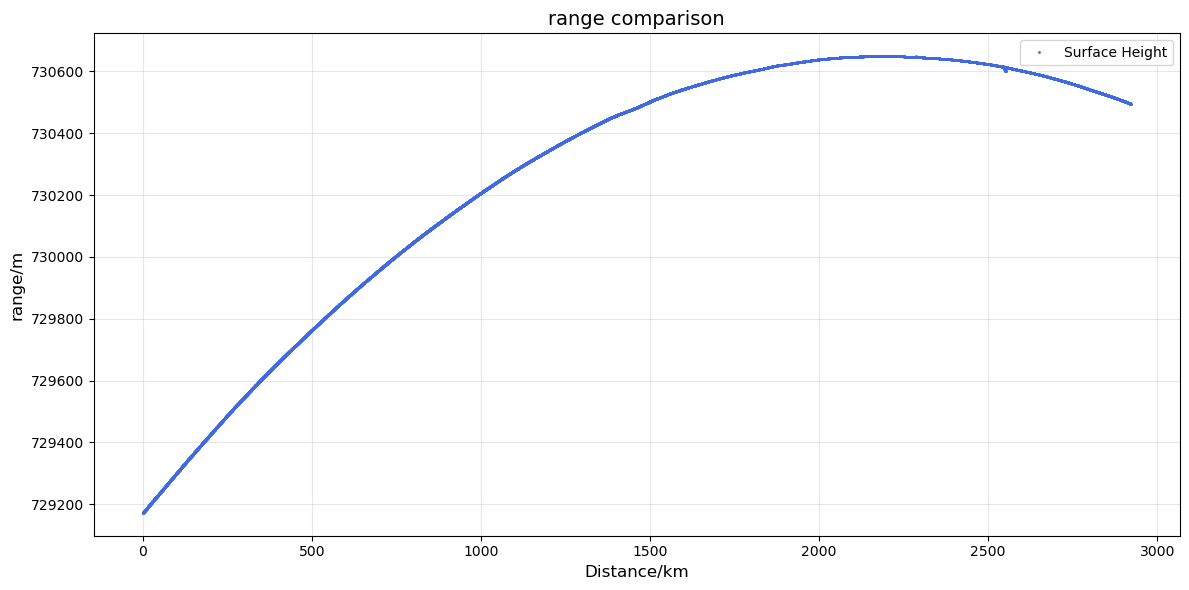

In [ ]:
import matplotlib.pyplot as plt

# 示例：df 中包含 'distance' 和 'height_1_20_ku' 列
plt.figure(figsize=(12, 6))
#plt.plot(df_L2['distance'], df_L2['height_1_20_ku'], '.', color='royalblue', markersize=2, label='Surface Height')
plt.plot(df_L2['distance'], df_L2['range_1'], '.', color='royalblue', markersize=2, label='Surface Height')

# 可选平滑：移动平均 (window 可调)
window = 100
# smooth = df_L2['range_1'].rolling(window, center=True).mean()
# plt.plot(df_L2['distance'], smooth, color='darkorange', linewidth=2.5, label='Smoothed Surface Height')

plt.xlabel('Distance/km', fontsize=12)
plt.ylabel('range/m', fontsize=12)
plt.title('range comparison', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

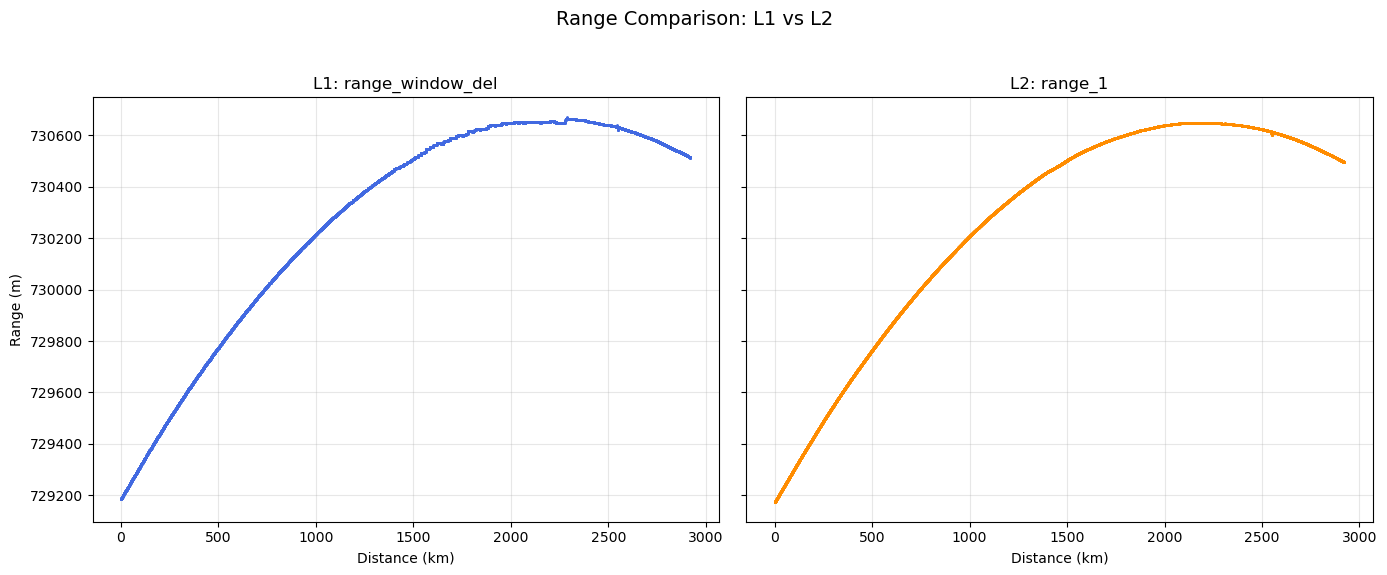

In [21]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 左图：L1 数据
axs[0].plot(df_L1['distance'], df_L1['range_window_del'], '.', color='royalblue', markersize=2)
axs[0].set_title('L1: range_window_del')
axs[0].set_xlabel('Distance (km)')
axs[0].set_ylabel('Range (m)')
axs[0].grid(alpha=0.3)

# 右图：L2 数据
axs[1].plot(df_L2['distance'], df_L2['range_1'], '.', color='darkorange', markersize=2)
axs[1].set_title('L2: range_1')
axs[1].set_xlabel('Distance (km)')
axs[1].grid(alpha=0.3)

plt.suptitle('Range Comparison: L1 vs L2', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## plot L1 surface height & L2_height_01

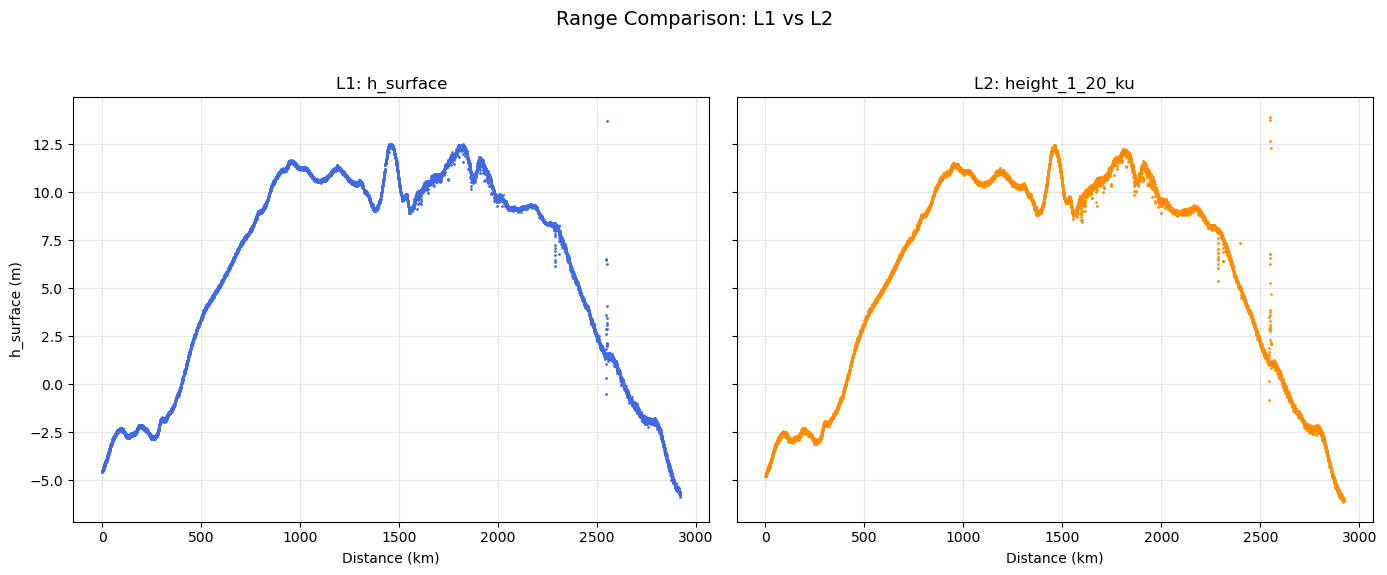

In [23]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 左图：L1 数据
axs[0].plot(df_L1['distance'], df_L1['h_surface'], '.', color='royalblue', markersize=2)
axs[0].set_title('L1: h_surface')
axs[0].set_xlabel('Distance (km)')
axs[0].set_ylabel('h_surface (m)')
axs[0].grid(alpha=0.3)

# 右图：L2 数据
axs[1].plot(df_L2['distance'], df_L2['height_1_20_ku'], '.', color='darkorange', markersize=2)
axs[1].set_title('L2: height_1_20_ku')
axs[1].set_xlabel('Distance (km)')
axs[1].grid(alpha=0.3)

plt.suptitle('Range Comparison: L1 vs L2', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

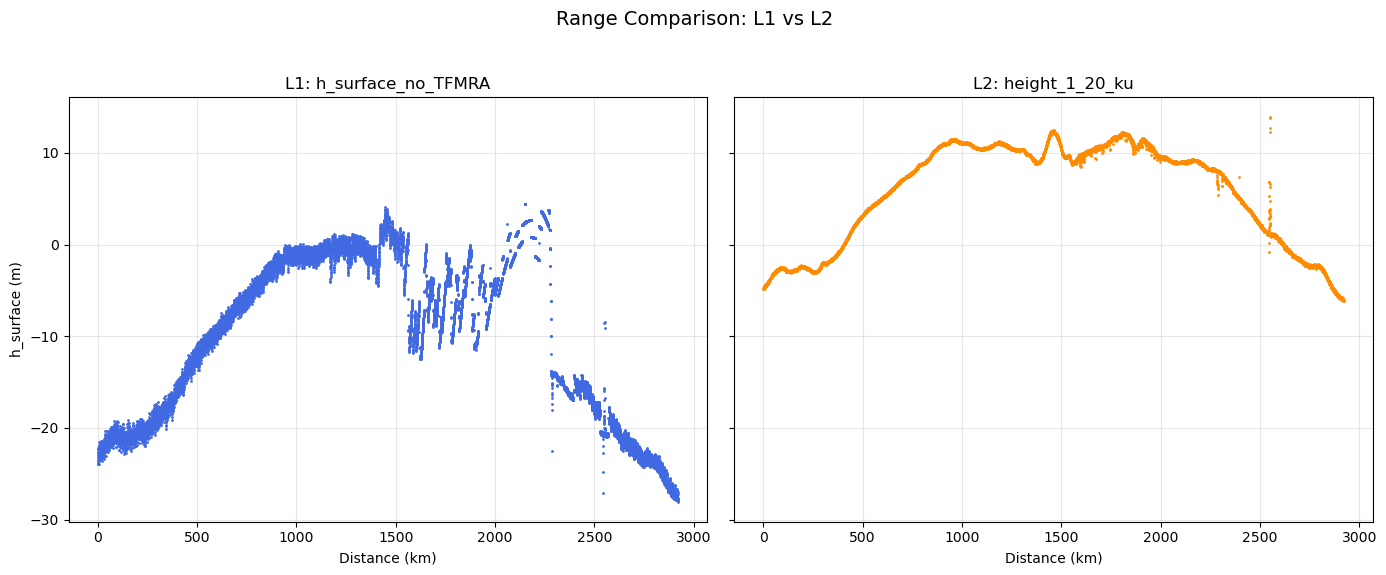

In [43]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 左图：L1 数据
axs[0].plot(df_L1['distance'], df_L1['h_surface_no_TFMRA'], '.', color='royalblue', markersize=2)
axs[0].set_title('L1: h_surface_no_TFMRA')
axs[0].set_xlabel('Distance (km)')
axs[0].set_ylabel('h_surface (m)')
axs[0].grid(alpha=0.3)

# 右图：L2 数据
axs[1].plot(df_L2['distance'], df_L2['height_1_20_ku'], '.', color='darkorange', markersize=2)
axs[1].set_title('L2: height_1_20_ku')
axs[1].set_xlabel('Distance (km)')
axs[1].grid(alpha=0.3)

plt.suptitle('Range Comparison: L1 vs L2', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

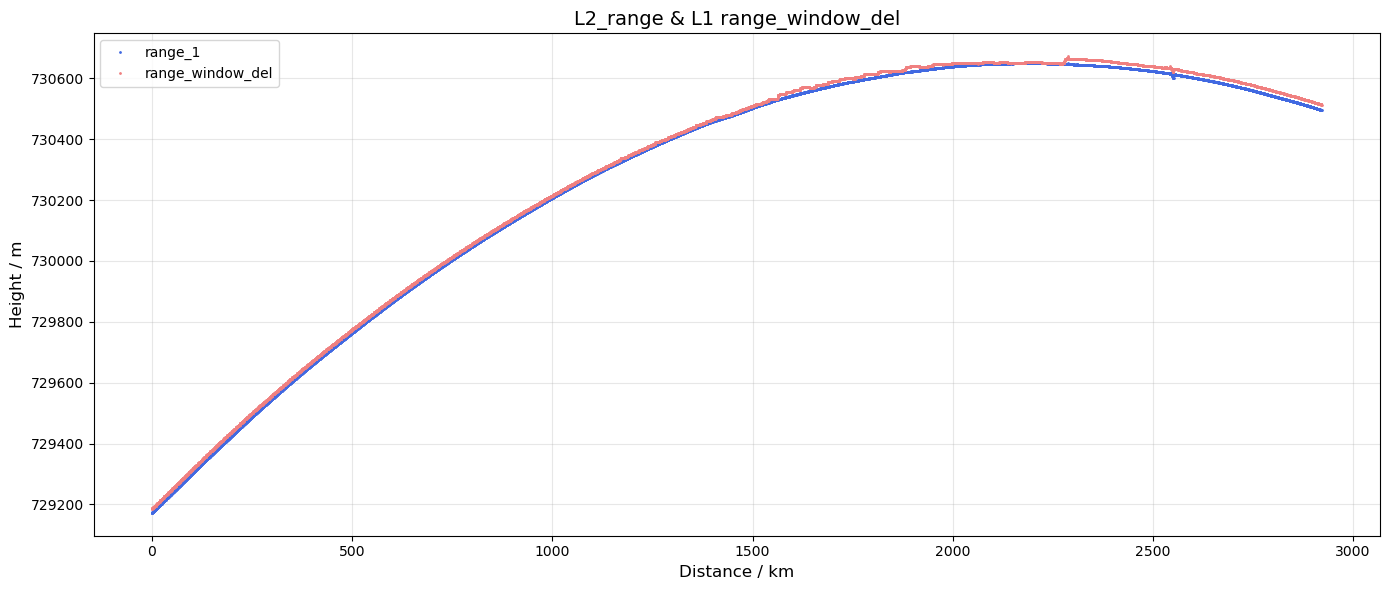

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# 原始点：mss_seaIce
plt.plot(df_L2['distance'], df_L2['range_1'], '.', color='royalblue', markersize=2, label='range_1')

# 原始点：mss_interp
plt.plot(df_L1['distance'], df_L1['range_window_del'], '.', color='lightcoral', markersize=2, label='range_window_del')


# 图形设置
plt.xlabel('Distance / km', fontsize=12)
plt.ylabel('Height / m', fontsize=12)
plt.title('L2_range & L1 range_window_del', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
print(df_L2)

## plot L1 ssha & L2_ssha

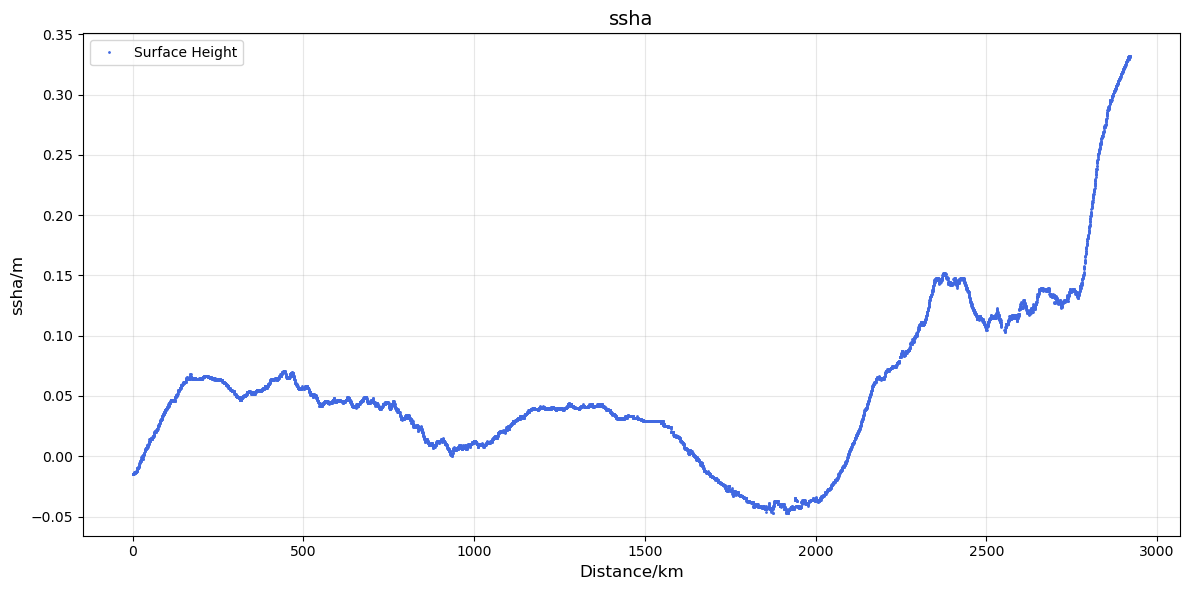

In [60]:
import matplotlib.pyplot as plt

# 示例：df 中包含 'distance' 和 'height_1_20_ku' 列
plt.figure(figsize=(12, 6))
#plt.plot(df_L2['distance'], df_L2['height_1_20_ku'], '.', color='royalblue', markersize=2, label='Surface Height')
plt.plot(df_L2['distance'], df_L2['ssha'], '.', color='royalblue', markersize=2, label='Surface Height')

# 可选平滑：移动平均 (window 可调)
window = 100
# smooth = df_L2['range_1'].rolling(window, center=True).mean()
# plt.plot(df_L2['distance'], smooth, color='darkorange', linewidth=2.5, label='Smoothed Surface Height')

plt.xlabel('Distance/km', fontsize=12)
plt.ylabel('ssha/m', fontsize=12)
plt.title('ssha', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## plot h surface and mean sea surface

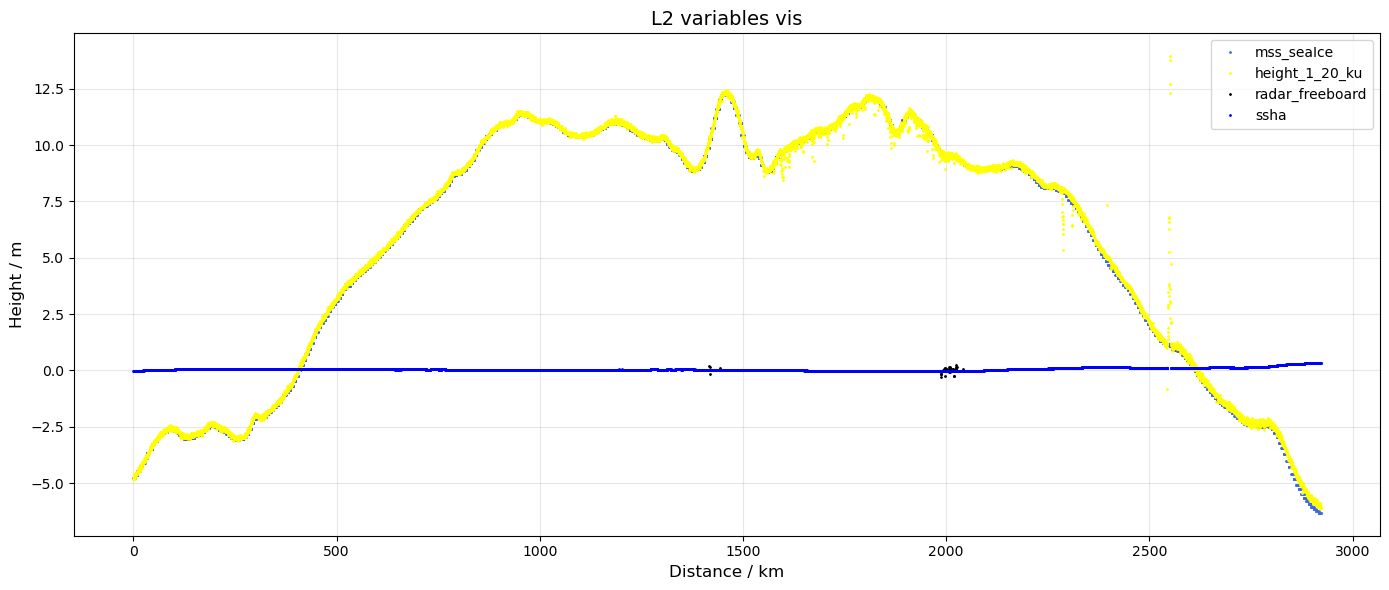

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# 原始点：mss_seaIce
plt.plot(df_L2['distance'], df_L2['mss_seaIce'], '.', color='royalblue', markersize=2, label='mss_seaIce')

# # 原始点：mss_interp
plt.plot(df_L2['distance'], df_L2['height_1_20_ku'], '.', color='yellow', markersize=2, label='height_1_20_ku')

plt.plot(df_L2['distance'], df_L2['radar_freeboard'], '.', color='black', markersize=2, label='radar_freeboard')
plt.plot(df_L2['distance'], df_L2['ssha'], '.', color='blue', markersize=2, label='ssha')

# 平滑曲线：mss_seaIce
#smooth_seaIce = df_L2['mss_seaIce'].rolling(window=100, center=True).mean()
#plt.plot(df_L2['distance'], smooth_seaIce, color='darkblue', linewidth=2.5, label='Smoothed mss_seaIce')

# 平滑曲线：mss_interp
#smooth_interp = df_L2['mss_interp'].rolling(window=100, center=True).mean()
#plt.plot(df_L2['distance'], smooth_interp, color='darkred', linewidth=2.5, label='Smoothed mss_interp')

# 图形设置
plt.xlabel('Distance / km', fontsize=12)
plt.ylabel('Height / m', fontsize=12)
plt.title('L2 variables vis', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

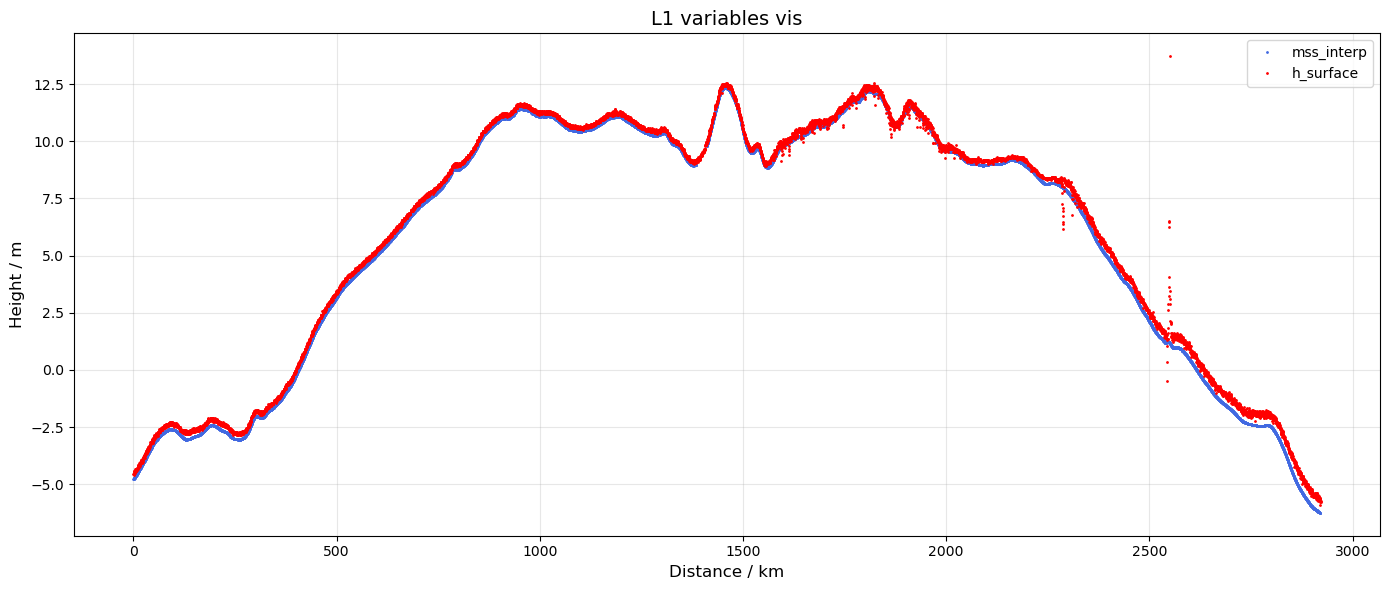

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# 原始点：mss_seaIce
plt.plot(df_L1['distance'], df_L1['mss_interp'], '.', color='royalblue', markersize=2, label='mss_interp')

# # 原始点：mss_interp
plt.plot(df_L1['distance'], df_L1['h_surface'], '.', color='red', markersize=2, label='h_surface')

# plt.plot(df_L2['distance'], df_L2['radar_freeboard'], '.', color='black', markersize=2, label='radar_freeboard')
# plt.plot(df_L2['distance'], df_L2['ssha'], '.', color='blue', markersize=2, label='ssha')

# 平滑曲线：mss_seaIce
#smooth_seaIce = df_L2['mss_seaIce'].rolling(window=100, center=True).mean()
#plt.plot(df_L2['distance'], smooth_seaIce, color='darkblue', linewidth=2.5, label='Smoothed mss_seaIce')

# 平滑曲线：mss_interp
#smooth_interp = df_L2['mss_interp'].rolling(window=100, center=True).mean()
#plt.plot(df_L2['distance'], smooth_interp, color='darkred', linewidth=2.5, label='Smoothed mss_interp')

# 图形设置
plt.xlabel('Distance / km', fontsize=12)
plt.ylabel('Height / m', fontsize=12)
plt.title('L1 variables vis', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

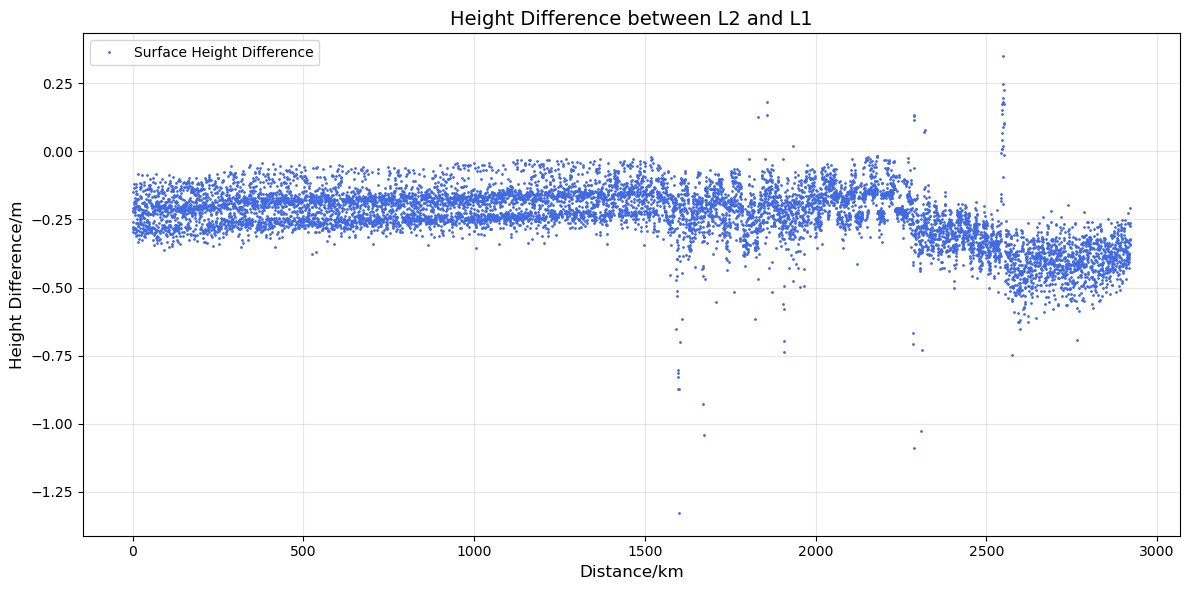

In [21]:
diff = df_L2['height_1_20_ku'] - df_L1['h_surface']
plt.figure(figsize=(12, 6)) 
plt.plot(df_L2['distance'], diff, '.', color='royalblue', markersize=2, label='Surface Height Difference')
plt.xlabel('Distance/km', fontsize=12)
plt.ylabel('Height Difference/m', fontsize=12)
plt.title('Height Difference between L2 and L1', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


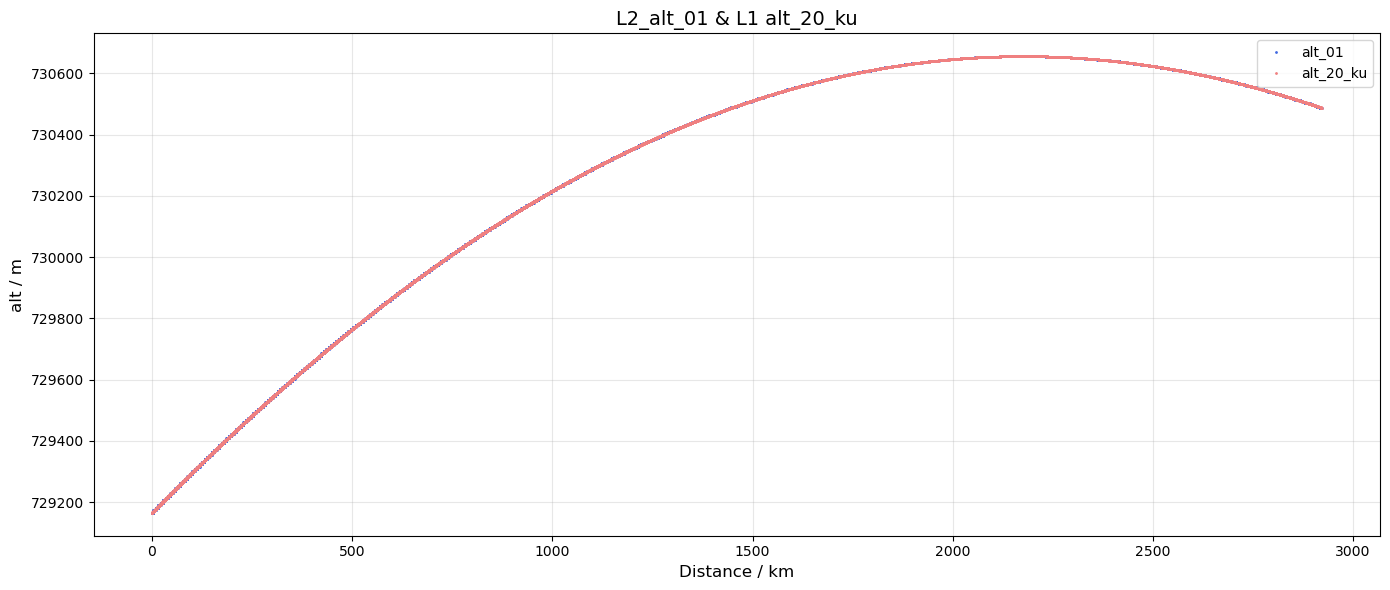

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# 原始点：mss_seaIce
plt.plot(df_L2['distance'], df_L2['alt'], '.', color='royalblue', markersize=2, label='alt_01')

# 原始点：mss_interp
plt.plot(df_L1['distance'], df_L1['alt'], '.', color='lightcoral', markersize=2, label='alt_20_ku')


# 图形设置
plt.xlabel('Distance / km', fontsize=12)
plt.ylabel('alt / m', fontsize=12)
plt.title('L2_alt_01 & L1 alt_20_ku', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

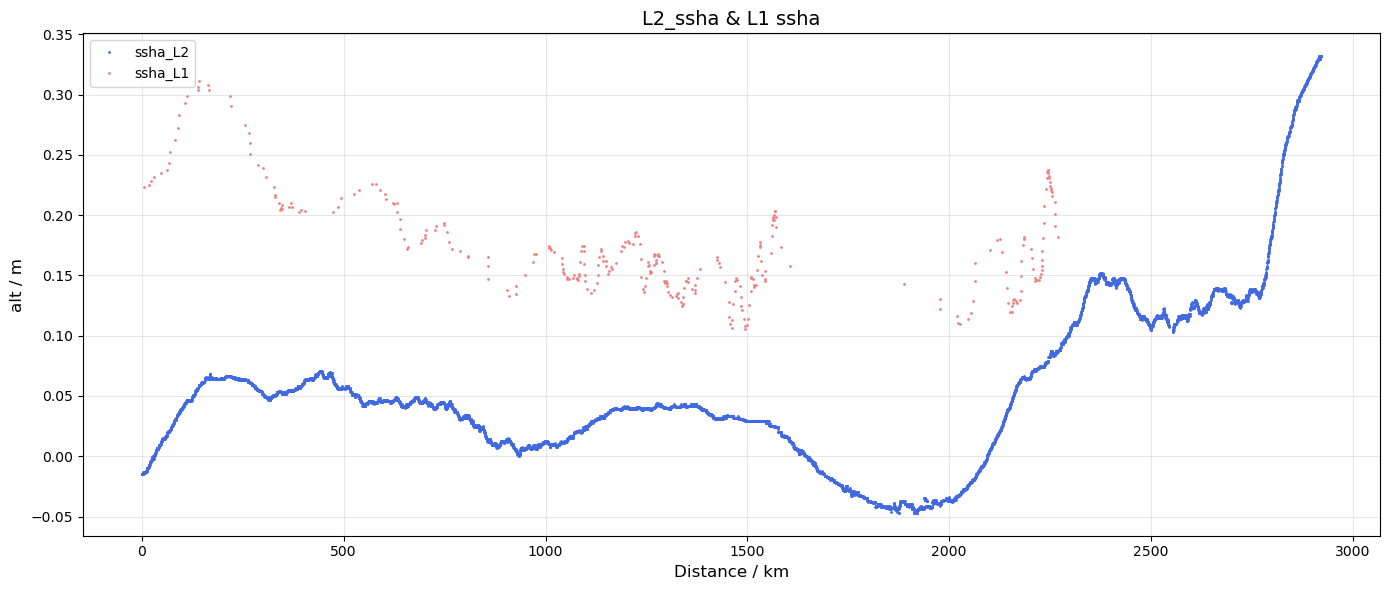

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# 原始点：mss_seaIce
plt.plot(df_L2['distance'], df_L2['ssha'], '.', color='royalblue', markersize=2, label='ssha_L2')

# 原始点：mss_interp
plt.plot(df_L1['distance'], df_L1['SLA'], '.', color='lightcoral', markersize=2, label='ssha_L1')


# 图形设置
plt.xlabel('Distance / km', fontsize=12)
plt.ylabel('alt / m', fontsize=12)
plt.title('L2_ssha & L1 ssha', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### type comparison

In [39]:
type_map_L2 = {
    0: 'lead',
    1: 'lead',
    2: 'ice',
    3: 'land'
}

df_L2['type_mapped'] = df_L2['surf_type'].map(type_map_L2)


### plot height_ice floe/ height_lead

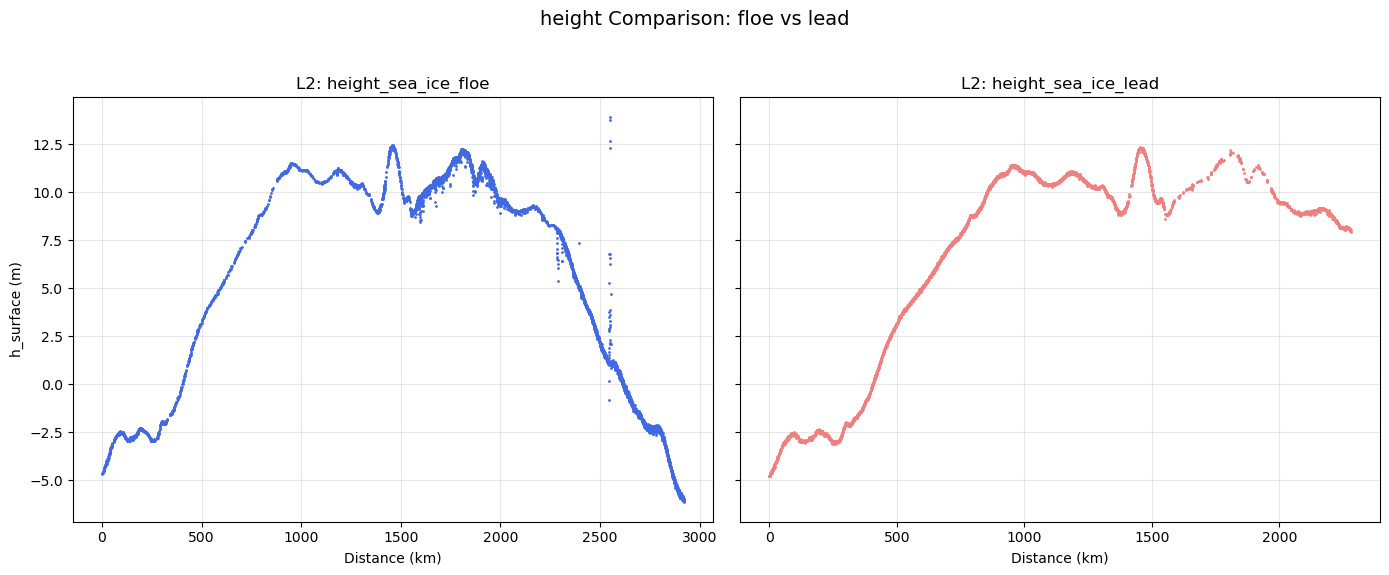

In [24]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 左图：L1 数据
axs[0].plot(df_L2['distance'], df_L2['height_sea_ice_floe'], '.', color='royalblue', markersize=2, label='height_sea_ice_floe')
axs[0].set_title('L2: height_sea_ice_floe')
axs[0].set_xlabel('Distance (km)')
axs[0].set_ylabel('h_surface (m)')
axs[0].grid(alpha=0.3)

# 右图：L2 数据
axs[1].plot(df_L2['distance'], df_L2['height_sea_ice_lead'], '.', color='lightcoral', markersize=2, label='height_sea_ice_lead')
axs[1].set_title('L2: height_sea_ice_lead')
axs[1].set_xlabel('Distance (km)')
axs[1].grid(alpha=0.3)

plt.suptitle('height Comparison: floe vs lead', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

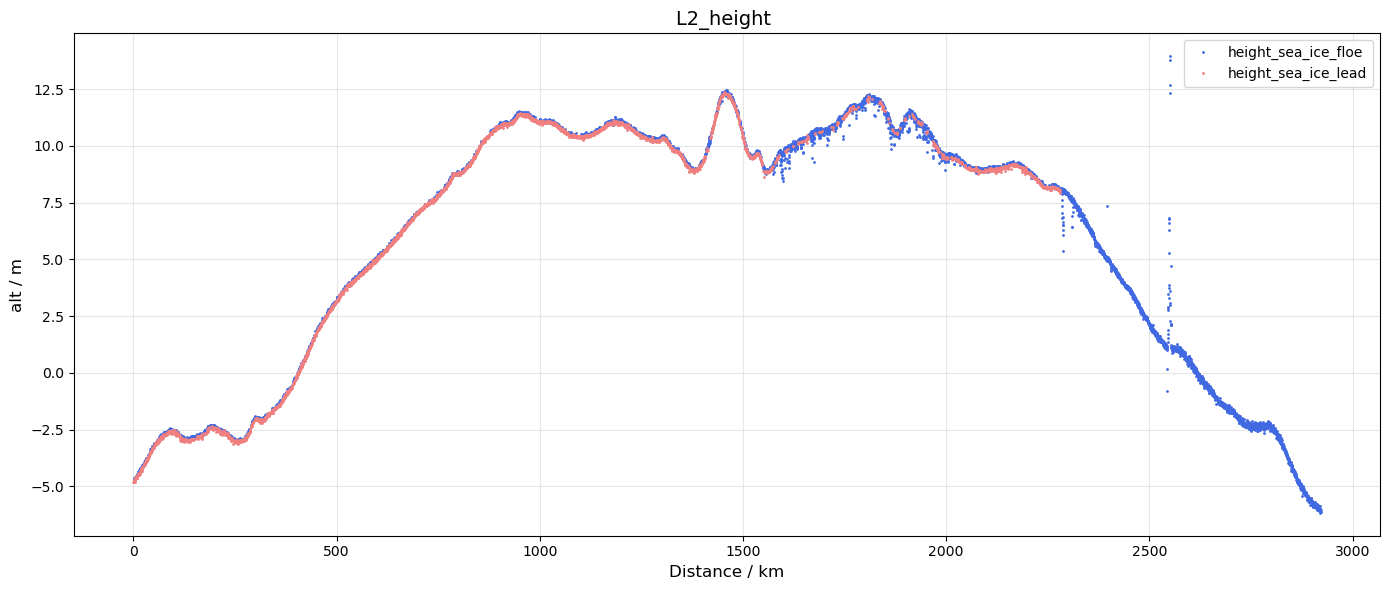

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# 原始点：mss_seaIce
plt.plot(df_L2['distance'], df_L2['height_sea_ice_floe'], '.', color='royalblue', markersize=2, label='height_sea_ice_floe')

# 原始点：mss_interp
plt.plot(df_L2['distance'], df_L2['height_sea_ice_lead'], '.', color='lightcoral', markersize=2, label='height_sea_ice_lead')


# 图形设置
plt.xlabel('Distance / km', fontsize=12)
plt.ylabel('alt / m', fontsize=12)
plt.title('L2_height ', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
print(df_L1.head())

                       time_20_ku                   utc_time         alt  \
14  2022-08-24 05:22:04.569960960 2022-08-24 05:22:04.569961  729170.465   
62  2022-08-24 05:22:06.733826944 2022-08-24 05:22:06.733827  729189.957   
73  2022-08-24 05:22:07.229724032 2022-08-24 05:22:07.229724  729194.407   
100 2022-08-24 05:22:08.446939008 2022-08-24 05:22:08.446939  729205.305   
152 2022-08-24 05:22:10.791277952 2022-08-24 05:22:10.791278  729226.190   

     noise_power_real  noise_linear   std          pp           k        lat  \
14            -172.33  5.847901e-18  0.85   67.419998   87.779999  77.393818   
62            -174.28  3.732502e-18  1.29   56.239998   71.779999  77.522562   
73            -172.79  5.260173e-18  1.14   71.070000   80.119995  77.552061   
100           -173.99  3.990249e-18  0.77   76.869995  124.360001  77.624460   
152           -174.57  3.491403e-18  0.69  105.220001  135.839996  77.763866   

            lon  ...  range_window_del      temp  mss_interp c

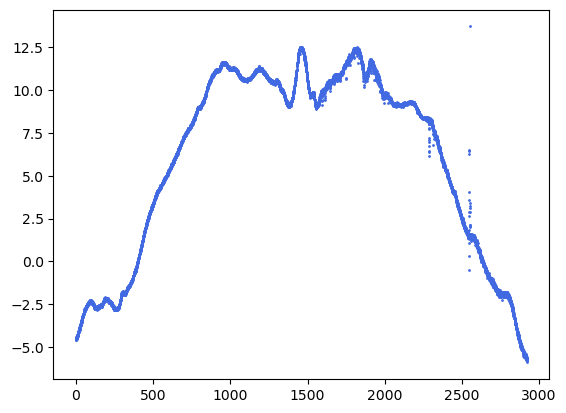

In [26]:
plt.plot(df_L1['distance'], df_L1['h_surface'], '.', color='royalblue', markersize=2, label='height_sea_ice_floe')
plt.show()

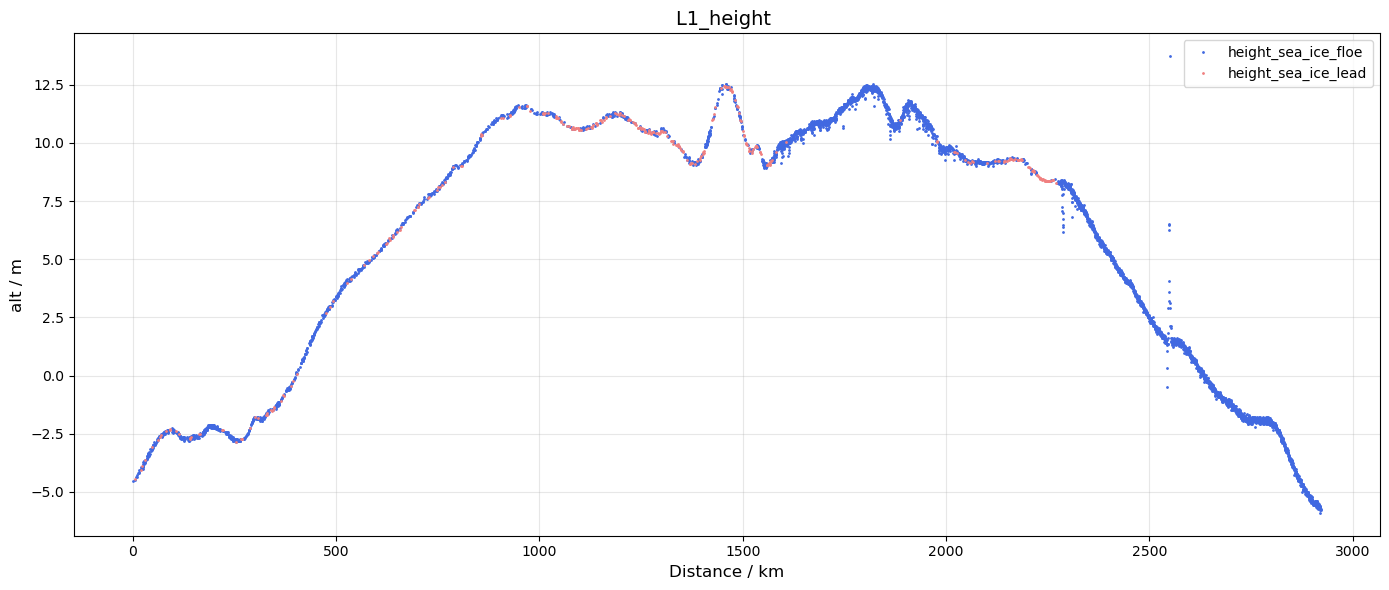

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# 原始点：mss_seaIce
plt.plot(df_L1['distance'], df_L1['height_sea_ice_floe'], '.', color='royalblue', markersize=2, label='height_sea_ice_floe')

# 原始点：mss_interp
plt.plot(df_L1['distance'], df_L1['height_sea_ice_lead'], '.', color='lightcoral', markersize=2, label='height_sea_ice_lead')


# 图形设置
plt.xlabel('Distance / km', fontsize=12)
plt.ylabel('alt / m', fontsize=12)
plt.title('L1_height ', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

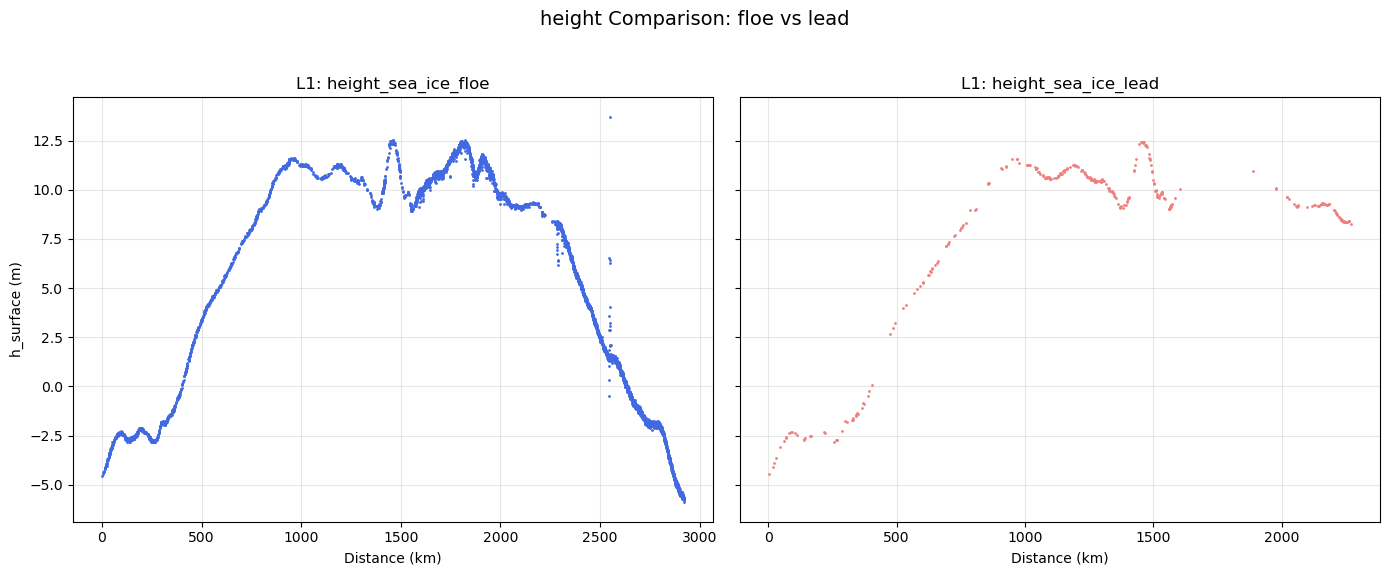

In [27]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# 左图：L1 数据
axs[0].plot(df_L1['distance'], df_L1['height_sea_ice_floe'], '.', color='royalblue', markersize=2, label='height_sea_ice_floe')
axs[0].set_title('L1: height_sea_ice_floe')
axs[0].set_xlabel('Distance (km)')
axs[0].set_ylabel('h_surface (m)')
axs[0].grid(alpha=0.3)

# 右图：L2 数据
axs[1].plot(df_L1['distance'], df_L1['height_sea_ice_lead'], '.', color='lightcoral', markersize=2, label='height_sea_ice_lead')
axs[1].set_title('L1: height_sea_ice_lead')
axs[1].set_xlabel('Distance (km)')
axs[1].grid(alpha=0.3)

plt.suptitle('height Comparison: floe vs lead', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### check the calculation of height_lead - mss 

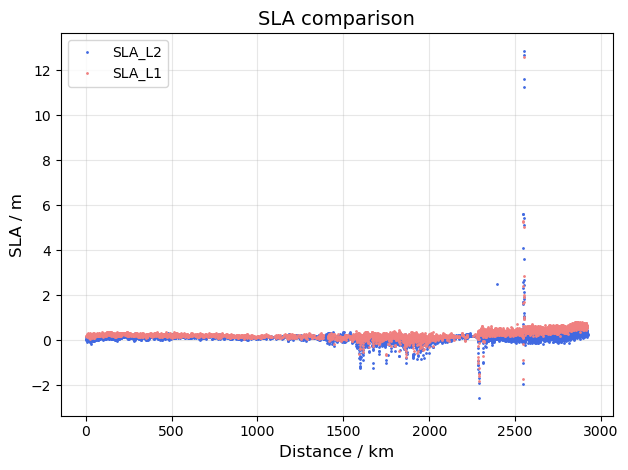

In [31]:
df_L2['SLA'] = df_L2['height_sea_ice_floe'] - df_L2['mss_seaIce']
df_L1['SLA'] = df_L1['height_sea_ice_floe'] - df_L1['mss_interp']

plt.plot(df_L2['distance'], df_L2['SLA'], '.', color='royalblue', markersize=2, label='SLA_L2')
plt.plot(df_L1['distance'], df_L1['SLA'], '.', color='lightcoral', markersize=2, label='SLA_L1')
plt.xlabel('Distance / km', fontsize=12)        
plt.ylabel('SLA / m', fontsize=12)
plt.title('SLA comparison', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

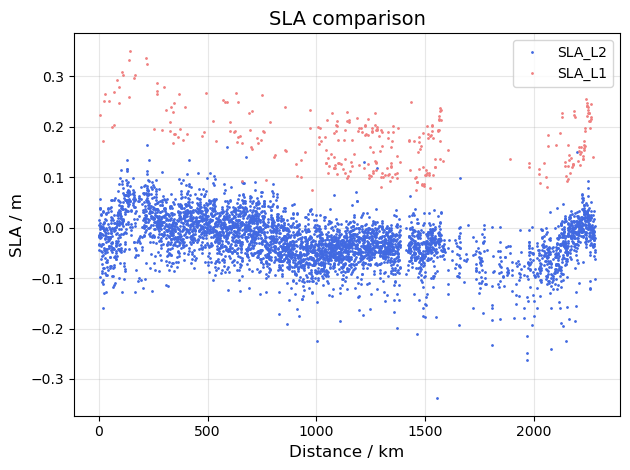

In [47]:
df_L2['SLA'] = df_L2['height_sea_ice_lead'] - df_L2['mss_interp']
df_L1['SLA'] = df_L1['height_sea_ice_lead'] - df_L1['mss_interp']

plt.plot(df_L2['distance'], df_L2['SLA'], '.', color='royalblue', markersize=2, label='SLA_L2')
plt.plot(df_L1['distance'], df_L1['SLA'], '.', color='lightcoral', markersize=2, label='SLA_L1')
plt.xlabel('Distance / km', fontsize=12)        
plt.ylabel('SLA / m', fontsize=12)
plt.title('SLA comparison', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

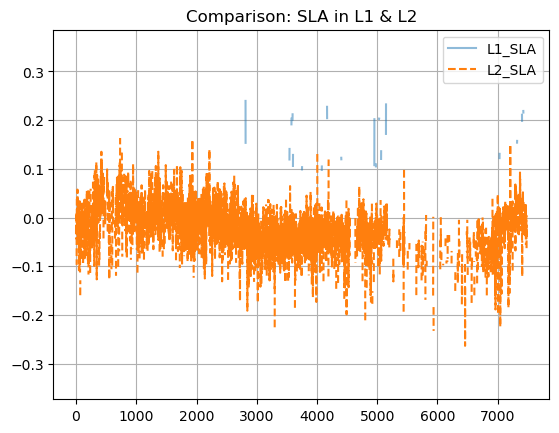

In [42]:
# 可视化对比 h_surface 和 height_sea_ice_lead
plt.plot(df_L1['SLA'], label='L1_SLA', alpha=0.5)
plt.plot(df_L2['SLA'], label='L2_SLA', linestyle='--')
plt.legend()
plt.title("Comparison: SLA in L1 & L2")
plt.grid(True)
plt.show()

L2 SLA interplation

In [48]:
from scipy.ndimage import uniform_filter1d
from scipy.interpolate import interp1d
import numpy as np

SLA_raw_values = df_L2['SLA']
# Step 1: Box 平滑 (100 km)
SLA_smoothed = uniform_filter1d(SLA_raw_values, size=5, mode='nearest')  # 滑动窗口平滑

# Step 2: 线性插值
lead_indices = df_L2[df_L2['SLA'].notnull()].index
interp_func = interp1d(lead_indices, SLA_smoothed[lead_indices], kind='linear', bounds_error=False, fill_value="extrapolate")
df_L2['SLA'] = interp_func(df_L2.index)

# Step 3: 二次 Box 平滑 (100 km)
df_L2['SLA'] = uniform_filter1d(df_L2['SLA'], size=5, mode='nearest')

# # Step 4: 超过 200 km 设为 NaN
# df_L2['distance_to_nearest_lead'] = df_L2.index.to_series().apply(lambda x: np.abs(lead_indices - x).min())
# df_L2.loc[df_L2['distance_to_nearest_lead'] > 200, 'SLA'] = np.nan

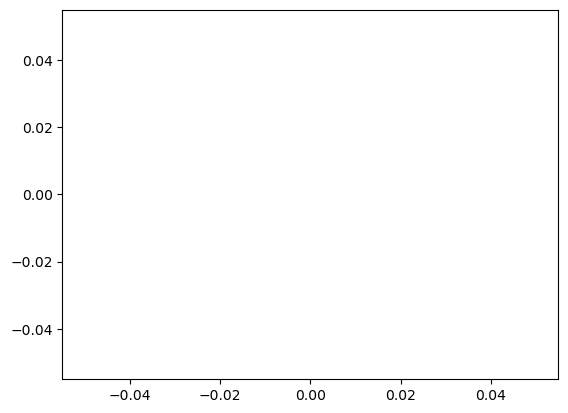

In [49]:
plt.plot(df_L2['SLA'])
plt.show()